# Temporal Botnet Detection using Graph Neural Networks (GNNs) & SMOTE Augmentation
**Course / Project**: AIML 505 - Group F Project  
**Dataset**: [UNSW 2018 Bot-IoT Dataset](https://research.unsw.edu.au/projects/bot-iot-dataset)  
**Primary Dataset File**: `Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv`  

---

### Group F Team Members
1. **Fardin Rahman** — ID: `2026-2-74-006`  
2. **Jubayer Alam Likhon** — ID: `2026-2-74-004`  

---

## 📌 Interactive Notebook Navigation Panel

| Section | Description | Quick Link |
| :--- | :--- | :---: |
| **1. Executive Summary & Objective** | Project Overview, IoT Intrusion & GNN Framework | [Go to Section 1](#sec-1) |
| **2. Dataset Ingestion** | Full UNSW 2018 Bot-IoT Dataset Ingestion & EDA | [Go to Section 2](#sec-2) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **2.1 Class Distributions** | Attack Category & Subcategory Visualizations | [Go to Section 2.1](#sec-21) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **2.2 Descriptive Statistics** | Feature Moments, Skewness, Kurtosis & Outliers | [Go to Section 2.2](#sec-22) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **2.3 Feature Dependency** | Pearson Correlation & Mutual Information Scores | [Go to Section 2.3](#sec-23) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **2.4 Stationarity & ACF/PACF** | ADF Stationarity Test & Autocorrelation Analysis | [Go to Section 2.4](#sec-24) |
| **3. Feature Engineering & Node Mapping** | Label Encoding, StandardScaler & IP Node Mapping | [Go to Section 3](#sec-3) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **3.1 Category Label Encoding** | Attack Class Mapping to Numeric Targets | [Go to Section 3.1](#sec-31) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **3.2 Continuous Feature Scaling** | StandardScaler Normalization on Numerical Attributes | [Go to Section 3.2](#sec-32) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **3.3 Node ID Mapping** | Host IP Address Mapping to Node Indices | [Go to Section 3.3](#sec-33) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **3.4 Train/Test Partitioning** | 80/20 Stratified Train/Test Edge Mask Creation | [Go to Section 3.4](#sec-34) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **3.5 SMOTE Data Augmentation** | Synthetic Minority Oversampling & Disk Caching | [Go to Section 3.5](#sec-35) |
| **4. Dynamic Graph Construction** | 10 Snapshots Slicing & Topological Node Features | [Go to Section 4](#sec-4) |
| **5. Model Architectures** | MLP, GCN, GraphSAGE & Temporal LSTM-GNN Models | [Go to Section 5](#sec-5) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **5.1 Flow MLP Baseline** | Tabular Multi-Layer Perceptron Definition | [Go to Section 5.1](#sec-51) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **5.2 Spatial GCN** | Graph Convolutional Network Definition | [Go to Section 5.2](#sec-52) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **5.3 Spatial GraphSAGE** | Neighborhood Aggregating GraphSAGE Model | [Go to Section 5.3](#sec-53) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **5.4 Temporal LSTM-GNN** | Spatial GraphSAGE + Recurrent Memory Cell | [Go to Section 5.4](#sec-54) |
| **6. Model Training & Loss Curves** | Multi-epoch Model Training & Trajectory Plots | [Go to Section 6](#sec-6) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **6.1 Early Stopping** | Validation Loss Convergence & Weight Restoration | [Go to Section 6.1](#sec-61) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **6.2 Class-Weighted Loss** | Inverse Frequency Weighted Cross-Entropy | [Go to Section 6.2](#sec-62) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **6.3 Training Loop** | Epoch Iterations across Model Suite | [Go to Section 6.3](#sec-63) |
| **7. Hyperparameter Tuning** | Grid Search & Early Stopping Validation | [Go to Section 7](#sec-7) |
| **8. Comparative Metrics & Checkpoints** | Individual Loss & CM Plots, Reports & Saved Models | [Go to Section 8](#sec-8) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.1.1 Flow MLP Baseline** | MLP Individual Loss, CM & Classification Report | [Go to Sec 8.1.1](#sec-811) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.1.2 Spatial GCN** | GCN Individual Loss, CM & Classification Report | [Go to Sec 8.1.2](#sec-812) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.1.3 Spatial GraphSAGE** | GraphSAGE Individual Loss, CM & Report | [Go to Sec 8.1.3](#sec-813) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.1.4 Temporal LSTM-GNN** | LSTM-GNN Individual Loss, CM & Report | [Go to Sec 8.1.4](#sec-814) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.1.5 Comparative Summary** | Grid CM, ROC Curves, Loss Trajectories & Master CSV | [Go to Sec 8.1.5](#sec-815) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.1.6 Hypothesis Testing** | Paired t-test & Wilcoxon Test ($H_0$, p-value) | [Go to Sec 8.1.6](#sec-816) |
| &nbsp;&nbsp;&nbsp;&nbsp;↳ **8.2 Model Checkpoints** | Save Trained PyTorch Models (`Model/*.pt`) | [Go to Sec 8.2](#sec-82) |
| **9. Discussion & Key Findings** | Comprehensive Project Synthesis & Performance Analysis | [Go to Section 9](#sec-9) |

---

<a id="sec-1"></a>
# 1. Executive Summary & Objective

In modern Internet of Things (IoT) environments, cyber-attacks—including **Distributed Denial of Service (DDoS)**, **Denial of Service (DoS)**, **Reconnaissance (OS Fingerprinting & Service Scanning)**, **Keylogging**, and **Data Exfiltration/Theft**—exhibit complex topological communication structures and evolving temporal dynamics. In raw network flow data, attack categories suffer from severe class imbalance, where majority classes (`DDoS`, `DoS`) dominate (>98% of total traffic), while critical intrusive activities like `Reconnaissance` (~2.5%), `Normal` (~0.01%), and `Theft` (~0.002%) are extremely rare.

Traditional machine learning classifiers treat individual flow records as independent tabular instances, completely ignoring the underlying graph topology formed by interacting IP addresses as well as the dynamic temporal evolution of botnet activity over time.

### Proposed Spatial-Temporal Graph Neural Network (GNN) Framework
To address these limitations, this project develops an end-to-end **Spatial-Temporal Graph Neural Network (GNN)** framework for multi-class botnet intrusion detection:
1. **Dynamic Graph Representation**: Traffic flows are transformed into a sequence of temporal snapshot graphs $G_t = (V, E_t, X_t, E_{\text{attr},t})$ for $t \in \{1, \dots, T\}$, where nodes $V$ correspond to host IP addresses (source/destination) and directed edges $E_t$ represent active communication flows between host pairs.
2. **Dynamic Node & Edge Attributes**: Each node $v \in V$ is equipped with dynamic degree and traffic volume features $X_t \in \mathbb{R}^{|V| \times 4}$, while directed edges carry continuous 23-dimensional normalized flow metrics $E_{\text{attr},t}$.
3. **SMOTE Data Augmentation**: Synthetic Minority Over-sampling Technique (SMOTE) is applied exclusively to training flow records (`is_train == True`) to balance minority classes (`Reconnaissance`, `Normal`, `Theft`) while avoiding any data leakage into the evaluation test set.
4. **Model Architecture Comparison**: We design, implement, and evaluate four neural network architectures:
   - **Flow MLP Baseline**: Tabular multi-layer perceptron classifying individual flow attributes directly.
   - **Spatial GCN**: Graph Convolutional Network leveraging spectral graph convolutions and edge attribute concatenation.
   - **Spatial GraphSAGE**: Neighborhood-aggregating Inductive GNN operating over spatial network topologies.
   - **Temporal LSTM-GNN**: Spatial GraphSAGE combined with a Recurrent Memory (LSTM) cell operating across consecutive snapshot graphs to capture dynamic temporal evolution.

In [ ]:
import os
import time
import json
import warnings
import copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GCNConv, GATConv

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from pathlib import Path
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from scipy.stats import ttest_rel, wilcoxon

In [154]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target Execution Device: {device}")

PyTorch Version: 2.5.1
CUDA Available: True
Target Execution Device: cuda


In [155]:
# ==========================================================
# Centralized Global Hyperparameters & Experiment Config
# ==========================================================
CONFIG = {
    'epochs': 100,                      # Maximum training epochs per model
    'patience': 5,                      # Early stopping patience threshold
    'lr': 0.01,                         # Learning rate for Adam optimizer
    'hidden_dim': 128,                   # Hidden channels across MLP & GNN layers
    'dropout': 0.1,                     # Dropout regularization probability
    'n_snapshots': 20,                   # Number of dynamic temporal graph snapshots
    'seed': 42                          # Global random seed for reproducibility
}


# ==========================================================
# GLOBAL SMOTE CONFIGURATION
# ==========================================================
USE_SMOTE_CACHE = True             # True = Load cached augmented dataset if available
                                    # False = Always regenerate SMOTE dataset
SAVE_TO_CACHE = False               # True = Save to cache
                                    # False = Dont save

SMOTE_TARGET_COUNT_REC = 100_000  # Target samples for each minority class
SMOTE_TARGET_COUNT_NOR = 50_000 
SMOTE_TARGET_COUNT_THE = 50_000 

# ==========================================================
# Hyperparameter Tuning & Early Stopping Validation
# ==========================================================
HPTESV = False

In [156]:

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])


<a id="sec-2"></a>
# 2. Dataset Ingestion (Full UNSW 2018 Bot-IoT Dataset)

We ingest the **complete, full UNSW 2018 Bot-IoT dataset** (`Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv`) containing **3,668,522 network flow records** across 46 feature columns. 
The dataset captures realistic network traffic generated in an IoT environment subjected to various cyber-attack vectors. All attack categories (`DDoS`, `DoS`, `Reconnaissance`, `Normal`, `Theft`) and subcategories are loaded without downsampling to maintain raw class distributions for analysis.

In [157]:
csv_path = '../Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv'
if not os.path.exists(csv_path):
    csv_path = 'Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv'

def load_full_dataset(path):
    print(f"Loading FULL UNSW 2018 Bot-IoT Dataset from: {path}...")
    start_time = time.time()
    df_full = pd.read_csv(path, low_memory=False).sort_values('stime').reset_index(drop=True)
    elapsed = time.time() - start_time
    print(f"Full Dataset loaded in {elapsed:.2f} seconds.")
    return df_full

df = load_full_dataset(csv_path)

print(f"Loaded Full Dataset Size: {len(df):,} records")
print("Attack Category Distribution (Full Dataset):")
print(df['category'].value_counts())

print("Subcategory Distribution (Full Dataset):")
print(df['subcategory'].value_counts())



Loading FULL UNSW 2018 Bot-IoT Dataset from: Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv...
Full Dataset loaded in 11.69 seconds.
Loaded Full Dataset Size: 3,668,522 records
Attack Category Distribution (Full Dataset):
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64
Subcategory Distribution (Full Dataset):
subcategory
UDP                  1981230
TCP                  1593180
Service_Scan           73168
OS_Fingerprint         17914
HTTP                    2474
Normal                   477
Keylogging                73
Data_Exfiltration          6
Name: count, dtype: int64


<a id="sec-21"></a>
## 2.1 Exploratory Data Analysis & Class Distribution Visualizations

We conduct exploratory data analysis to inspect class imbalance across major attack categories (`DDoS`, `DoS`, `Reconnaissance`, `Normal`, `Theft`) and detailed attack subcategories (e.g., `UDP`, `TCP`, `Service_Scan`, `OS_Fingerprint`, `HTTP`, `Keylogging`, `Data_Exfiltration`). The logarithmic frequency plots highlight the extreme class imbalance inherent in real-world IoT network intrusion monitoring.

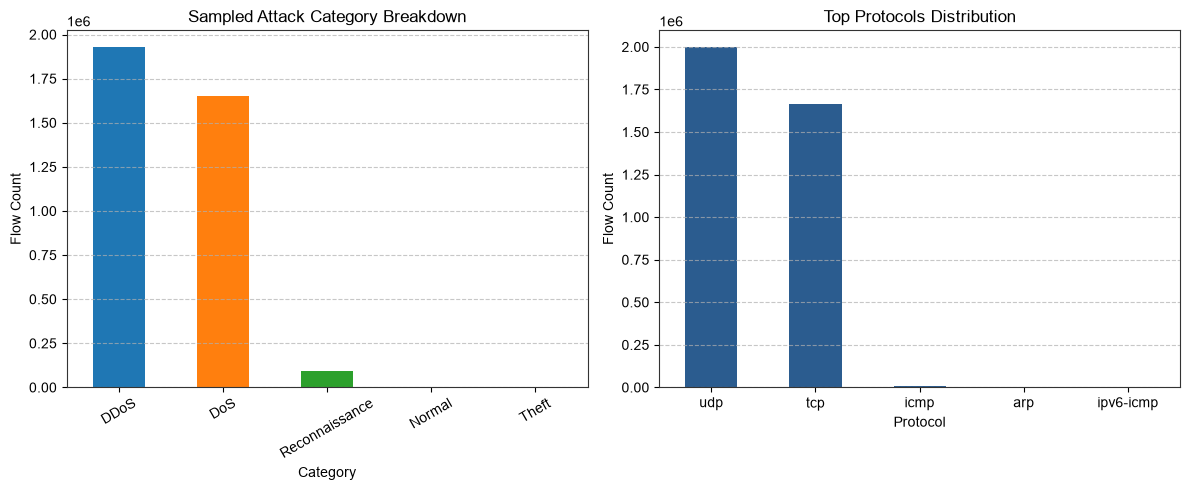

In [158]:
plt.figure(figsize=(12, 5))

# Plot 1: Attack Category Breakdown
plt.subplot(1, 2, 1)
df['category'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Sampled Attack Category Breakdown')
plt.xlabel('Category')
plt.ylabel('Flow Count')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Top Protocol Distribution
plt.subplot(1, 2, 2)
df['proto'].value_counts().head(5).plot(kind='bar', color='#2b5c8f')
plt.title('Top Protocols Distribution')
plt.xlabel('Protocol')
plt.ylabel('Flow Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


<a id="sec-22"></a>
## 2.2 Descriptive Statistics & Distribution Analysis

To establish a statistical baseline for key continuous flow variables (`dur`, `pkts`, `bytes`, `rate`, `sintpkt`, `dintpkt`, `swin`, `dwin`), we perform an empirical distribution analysis:
1. **Summary Statistics**: Mean, median, standard deviation, and interquartile range (IQR).
2. **Higher-Order Moments**: Skewness ($\gamma_1$) and Kurtosis ($\gamma_2$) to quantify distribution asymmetry and heavy-tailed behavior typical of cyber-attack traffic bursts.
3. **Outlier Detection**: Interquartile range (IQR) box plots and threshold analysis.

=== Descriptive Statistics & Distribution Moments ===
             mean            std   min         50%           max    skewness  \
dur     20.334789      21.487636   0.0   15.508524  2.771485e+03   41.091405   
pkts     7.725963     115.587643   1.0    7.000000  7.005700e+04  458.903142   
bytes  869.050061  112266.669281  60.0  600.000000  7.183334e+07  494.680980   
rate   244.940660    7919.940282   0.0    0.305840  1.000000e+06   92.116177   

            kurtosis  
dur      2745.131396  
pkts   234744.042207  
bytes  266548.292262  
rate    10479.540699  

=== Outlier Analysis (IQR Method) ===
Feature 'dur       ':     80,161 outliers (  2.19%)
Feature 'pkts      ':    140,466 outliers (  3.83%)
Feature 'bytes     ':      4,203 outliers (  0.11%)
Feature 'rate      ':    343,654 outliers (  9.37%)


<Figure size 1200x500 with 0 Axes>

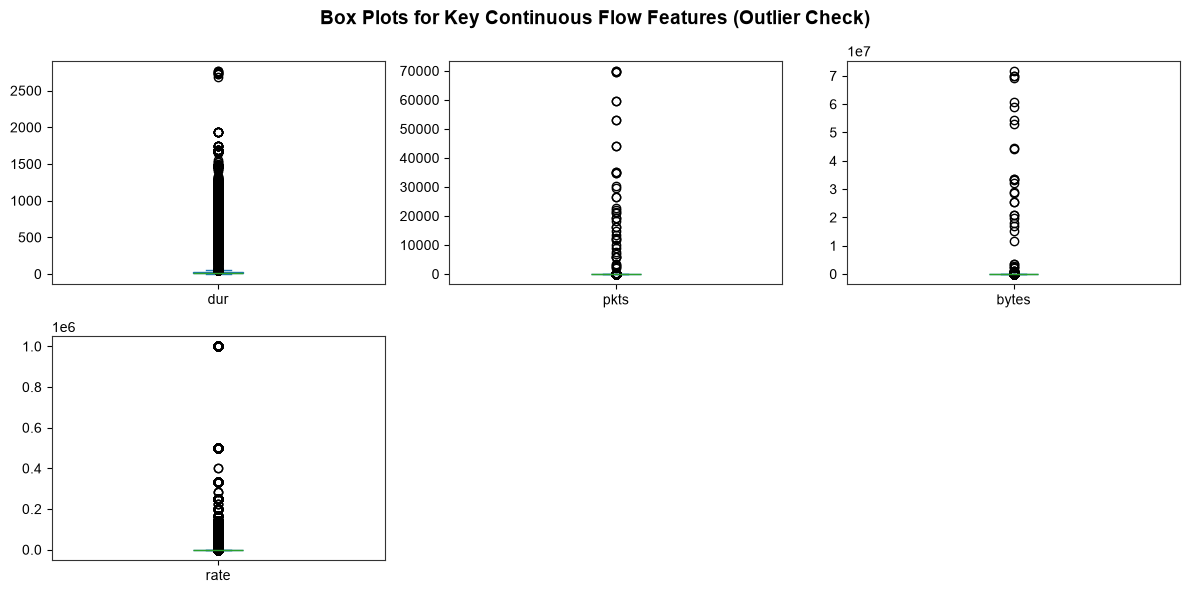

In [159]:
# 2.2 Descriptive Statistics & Distribution Analysis
from scipy.stats import skew, kurtosis

numeric_cols_sample = ['dur', 'pkts', 'bytes', 'rate', 'sintpkt', 'dintpkt', 'swin', 'dwin']
available_cols = [c for c in numeric_cols_sample if c in df.columns]

# Summary Statistics Table
stats_summary = df[available_cols].describe().T
stats_summary['skewness'] = df[available_cols].apply(lambda x: skew(x.dropna()))
stats_summary['kurtosis'] = df[available_cols].apply(lambda x: kurtosis(x.dropna()))

print("=== Descriptive Statistics & Distribution Moments ===")
print(stats_summary[['mean', 'std', 'min', '50%', 'max', 'skewness', 'kurtosis']])

# IQR Outlier Detection
print("\n=== Outlier Analysis (IQR Method) ===")
for col in available_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Feature '{col:10s}': {outliers:10,d} outliers ({outliers/len(df)*100:6.2f}%)")

# Boxplot Visualization
plt.figure(figsize=(12, 5))
df[available_cols[:6]].plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 6), patch_artist=True)
plt.suptitle("Box Plots for Key Continuous Flow Features (Outlier Check)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="sec-23"></a>
## 2.3 Feature Correlation, Covariance & Mutual Information Analysis

We conduct multivariate statistical dependency analysis across continuous flow attributes to motivate feature selection and graph edge attribute construction:
1. **Pearson Correlation Matrix ($r_{xy}$)**: Quantifies linear feature dependencies.
2. **Mutual Information Score ($I(X; Y)$)**: Measures non-linear dependency between numerical flow attributes and target attack categories $Y \in \{0, \dots, 4\}$.

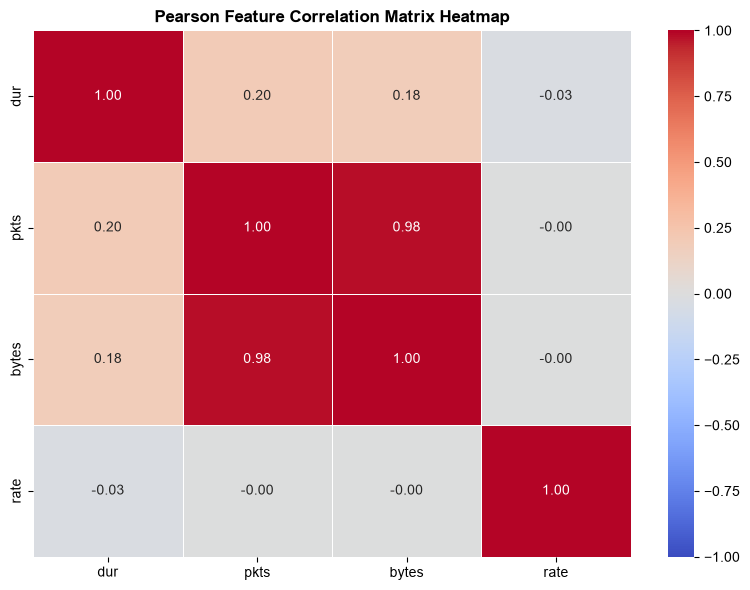

=== Mutual Information Scores (Target: Attack Category) ===
Feature  Mutual_Information
    dur            0.728517
   rate            0.573337
  bytes            0.280645
   pkts            0.159326


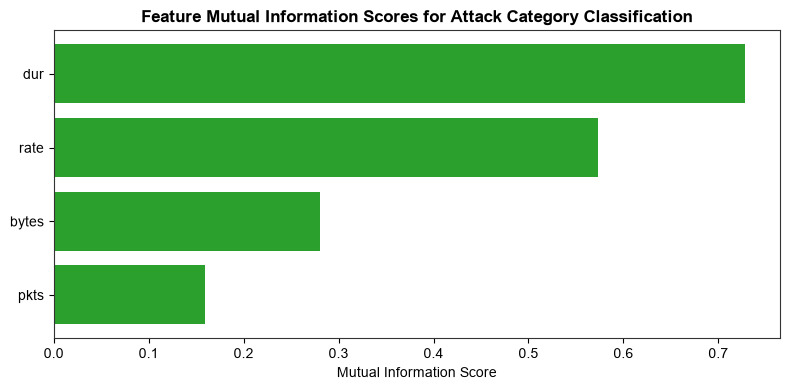

In [160]:


# Pearson Correlation Heatmap
corr_matrix = df[available_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Pearson Feature Correlation Matrix Heatmap", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Mutual Information Analysis relative to Category Index
sample_subset = df.sample(n=min(50000, len(df)), random_state=42)
target_cat = sample_subset['category_idx'] if 'category_idx' in sample_subset.columns else LabelEncoder().fit_transform(sample_subset['category'])
mi_scores = mutual_info_classif(sample_subset[available_cols], target_cat, random_state=42)
mi_df = pd.DataFrame({'Feature': available_cols, 'Mutual_Information': mi_scores}).sort_values('Mutual_Information', ascending=False)

print("=== Mutual Information Scores (Target: Attack Category) ===")
print(mi_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(mi_df['Feature'], mi_df['Mutual_Information'], color='#2ca02c')
plt.xlabel("Mutual Information Score")
plt.title("Feature Mutual Information Scores for Attack Category Classification", fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<a id="sec-24"></a>
## 2.4 Time-Series Stationarity (Augmented Dickey-Fuller) & Autocorrelation Analysis (ACF/PACF)

To statistically justify modeling network flows as dynamic temporal snapshot graphs, we evaluate the temporal stationarity and autocorrelation structure of traffic flow rates over time:
1. **Augmented Dickey-Fuller (ADF) Test**:
   - **Null Hypothesis ($H_0$)**: The traffic volume time-series has a unit root (is non-stationary).
   - **Alternative Hypothesis ($H_1$)**: The time-series has no unit root (is stationary).
2. **Autocorrelation (ACF) & Partial Autocorrelation (PACF)**: Quantifies temporal persistence and lag dependence across flow arrival rates.

=== Augmented Dickey-Fuller (ADF) Stationarity Test ===
ADF Statistic         : -79.906394
p-value               : 0.000000e+00
Lags Used             : 42
Number of Observations: 303634
Critical Values:
   1%   : -3.430372
   5%   : -2.861550
   10%  : -2.566775

Decision: Reject H0 (p < 0.05). The traffic rate time-series is stationary.


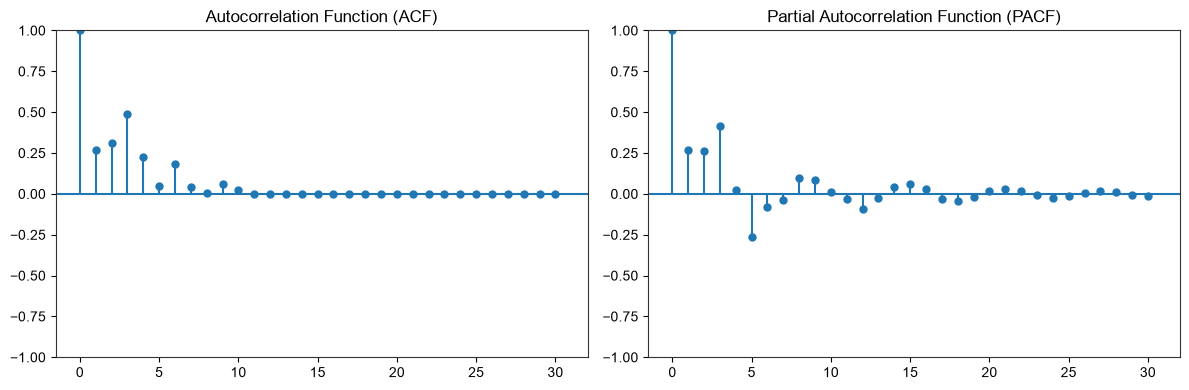

In [163]:
# 2.4 Stationarity Testing (ADF) & Autocorrelation (ACF/PACF)


# Aggregate flow volume per 10-second interval
df_ts = df.set_index(pd.to_datetime(df['stime'], unit='s')).resample('10s').size().rename('flow_count')

# Augmented Dickey-Fuller (ADF) Stationarity Test
adf_result = adfuller(df_ts.dropna())
print("=== Augmented Dickey-Fuller (ADF) Stationarity Test ===")
print(f"ADF Statistic         : {adf_result[0]:.6f}")
print(f"p-value               : {adf_result[1]:.6e}")
print(f"Lags Used             : {adf_result[2]}")
print(f"Number of Observations: {adf_result[3]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key:5s}: {value:.6f}")

if adf_result[1] < 0.05:
    print("\nDecision: Reject H0 (p < 0.05). The traffic rate time-series is stationary.")
else:
    print("\nDecision: Fail to reject H0 (p >= 0.05). The traffic rate time-series is non-stationary.")

# ACF & PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df_ts.dropna(), ax=axes[0], lags=30, title="Autocorrelation Function (ACF)")
plot_pacf(df_ts.dropna(), ax=axes[1], lags=30, title="Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

<a id="sec-3"></a>
# 3. Feature Engineering & Node Mapping

In this section, we process raw tabular network flow data into continuous numerical feature representations and map network IP addresses to graph node indices.

<a id="sec-31"></a>
### 3.1 Attack Category Label Encoding
We map target attack categories (`DDoS`, `DoS`, `Reconnaissance`, `Normal`, `Theft`) to integer class indices $y \in \{0, 1, 2, 3, 4\}$ using `sklearn.preprocessing.LabelEncoder`.

<a id="sec-32"></a>
### 3.2 Continuous Feature Standardization
We extract 23 continuous flow features (e.g., flow duration `dur`, packet counts `pkts`, byte volumes `bytes`, rates `rate`, inter-arrival times `sintpkt`/`dintpkt`, TCP window sizes `swin`/`dwin`) and scale them using `StandardScaler` to ensure zero mean and unit variance across all input dimensions.

<a id="sec-33"></a>
### 3.3 IP Address Node ID Mapping
We combine all unique source IP addresses (`saddr`) and destination IP addresses (`daddr`) into a global node set $V$. Each unique IP is assigned a discrete integer node ID $u \in \{0, \dots, N-1\}$, establishing the foundational node space for graph construction.

In [164]:
# Label encoding for attack categories
cat_encoder = LabelEncoder()
df['category_idx'] = cat_encoder.fit_transform(df['category'])
num_classes = len(cat_encoder.classes_)
class_names = list(cat_encoder.classes_)
print("Target Class Map:", dict(enumerate(class_names)))

# Continuous numerical flow attributes for edge features
numeric_cols = [
    'pkts', 'bytes', 'dur', 'mean', 'stddev', 'sum', 'min', 'max',
    'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
    'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP',
    'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'state_number', 'proto_number'
]

# Handle null values and scale features
df[numeric_cols] = df[numeric_cols].fillna(0)
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Map source and destination IP addresses to unique graph node IDs
all_ips = pd.concat([df['saddr'], df['daddr']]).unique()
ip_map = {ip: i for i, ip in enumerate(all_ips)}
num_nodes = len(ip_map)

df['src_idx'] = df['saddr'].map(ip_map)
df['dst_idx'] = df['daddr'].map(ip_map)

print(f"Total Unique Graph Nodes (IP Addresses): {num_nodes:,}")
print(f"Total Network Flow Edges: {len(df):,}")


Target Class Map: {0: 'DDoS', 1: 'DoS', 2: 'Normal', 3: 'Reconnaissance', 4: 'Theft'}
Total Unique Graph Nodes (IP Addresses): 93
Total Network Flow Edges: 3,668,522


### 3.4 Train Test Split

In [165]:
# Stratified train/test edge mask generation across categories
np.random.seed(CONFIG['seed'])
train_indices = []
test_indices = []

for cat_idx in range(num_classes):
    idx = df[df['category_idx'] == cat_idx].index.values.copy()
    np.random.shuffle(idx)
    n_tr = int(0.8 * len(idx))
    train_indices.extend(idx[:n_tr])
    test_indices.extend(idx[n_tr:])

df['is_train'] = False
df.loc[train_indices, 'is_train'] = True

# Display Train / Test Split Statistics
n_train = df['is_train'].sum()
n_test = (~df['is_train']).sum()
total_flows = len(df)

print("=== Stratified Train / Test Split Breakdown ===")
print(f"Total Flow Records: {total_flows:,}")
print(f"Train Flow Count (80%): {n_train:,} ({n_train / total_flows * 100:.2f}%)")
print(f"Test Flow Count  (20%): {n_test:,} ({n_test / total_flows * 100:.2f}%)")

print("\nCategory-wise Train / Test Split Breakdown:")
split_df = df.groupby(['category', 'is_train']).size().unstack(fill_value=0)
split_df.columns = ['Test Count (20%)', 'Train Count (80%)']
split_df['Total Count'] = split_df['Train Count (80%)'] + split_df['Test Count (20%)']
split_df['Train Ratio (%)'] = (split_df['Train Count (80%)'] / split_df['Total Count'] * 100).round(2)
print(split_df.to_string())


=== Stratified Train / Test Split Breakdown ===
Total Flow Records: 3,668,522
Train Flow Count (80%): 2,934,816 (80.00%)
Test Flow Count  (20%): 733,706 (20.00%)

Category-wise Train / Test Split Breakdown:
                Test Count (20%)  Train Count (80%)  Total Count  Train Ratio (%)
category                                                                         
DDoS                      385325            1541299      1926624            80.00
DoS                       330052            1320208      1650260            80.00
Normal                        96                381          477            79.87
Reconnaissance             18217              72865        91082            80.00
Theft                         16                 63           79            79.75


<a id="sec-3"></a>
# 3. Feature Engineering & Node Mapping

In this section, we process raw tabular network flow data into continuous numerical feature representations and map network IP addresses to graph node indices.


### 3.1 Attack Category Label Encoding
We map target attack categories (`DDoS`, `DoS`, `Reconnaissance`, `Normal`, `Theft`) to integer class indices $y \in \{0, 1, 2, 3, 4\}$ using `sklearn.preprocessing.LabelEncoder`.


### 3.2 Continuous Feature Standardization
We extract 23 continuous flow features (e.g., flow duration `dur`, packet counts `pkts`, byte volumes `bytes`, rates `rate`, inter-arrival times `sintpkt`/`dintpkt`, TCP window sizes `swin`/`dwin`) and scale them using `StandardScaler` to ensure zero mean and unit variance across all input dimensions.


### 3.3 IP Address Node ID Mapping
We combine all unique source IP addresses (`saddr`) and destination IP addresses (`daddr`) into a global node set $V$. Each unique IP is assigned a discrete integer node ID $u \in \{0, \dots, N-1\}$, establishing the foundational node space for graph construction.

In [166]:
# ==========================================================
# File path for disk caching the SMOTE-augmented dataset
# ==========================================================
aug_file_path = 'Dataset/All_features/UNSW_2018_IoT_Botnet_SMOTE_Augmented.csv'
if not os.path.exists(aug_file_path) and os.path.exists('../' + aug_file_path):
    aug_file_path = '../' + aug_file_path

if USE_SMOTE_CACHE and os.path.exists(aug_file_path):
    print(f"[CACHE HIT] Found saved SMOTE-augmented dataset on disk: {aug_file_path}")
    print("Loading pre-computed SMOTE augmented dataset...")
    start_t = time.time()
    df_augmented = pd.read_csv(aug_file_path, low_memory=False)
    print(f"Loaded augmented dataset in {time.time() - start_t:.2f} seconds. Total records: {len(df_augmented):,}")

    df_train_after = df_augmented[df_augmented['is_train']]
    train_dist_after = df_train_after['category'].value_counts()

    print("\n=== Training Class Distribution (Loaded from Disk) ===")
    print(train_dist_after)

else:
    print(f"[CACHE MISS] Augmented dataset '{aug_file_path}' not found on disk (or cache disabled). Executing SMOTE augmentation...")

    # Filter training dataset for SMOTE augmentation
    df_train = df[df['is_train']].copy()

    print("=== Training Class Distribution BEFORE SMOTE ===")
    train_dist_before = df_train['category'].value_counts()
    print(train_dist_before)

    # Define target sample counts for SMOTE augmentation on minority classes
    smote_target_counts = {
        cat_encoder.transform(['Reconnaissance'])[0]: SMOTE_TARGET_COUNT_REC,
        cat_encoder.transform(['Normal'])[0]: SMOTE_TARGET_COUNT_NOR,
        cat_encoder.transform(['Theft'])[0]: SMOTE_TARGET_COUNT_THE
    }

    X_tr = df_train[numeric_cols].values
    y_tr = df_train['category_idx'].values

    # Build sampling strategy (only oversample classes below target count)
    smote_strategy = {}
    for c_idx, target in smote_target_counts.items():
        current_count = (y_tr == c_idx).sum()
        if target > current_count:
            smote_strategy[c_idx] = target

    print(f"\nApplying SMOTE for minority classes: {[class_names[c] for c in smote_strategy.keys()]}")
    smote = SMOTE(
        sampling_strategy=smote_strategy,
        random_state=CONFIG['seed'],
        k_neighbors=5
    )

    X_resampled, y_resampled = smote.fit_resample(X_tr, y_tr)

    # Extract synthetic minority samples generated by SMOTE
    n_synthetic = len(X_resampled) - len(X_tr)
    synth_X = X_resampled[len(X_tr):]
    synth_y = y_resampled[len(y_tr):]

    synth_df = pd.DataFrame(synth_X, columns=numeric_cols)
    synth_df['category_idx'] = synth_y
    synth_df['category'] = cat_encoder.inverse_transform(synth_y)
    synth_df['is_train'] = True

    # Assign source/destination IP node indices and timestamps by sampling real training edges of the same class
    src_indices, dst_indices, stimes = [], [], []
    unique_synth_classes = np.unique(synth_y)

    for c in tqdm(unique_synth_classes, desc="Assigning Graph Topology & Timestamps to Synthetic Edges"):
        mask_synth = (synth_y == c)
        n_c_synth = mask_synth.sum()

        real_c_edges = df_train[df_train['category_idx'] == c]
        sampled_edges = real_c_edges.sample(
            n=n_c_synth,
            replace=True,
            random_state=CONFIG['seed']
        )

        src_indices.extend(sampled_edges['src_idx'].values)
        dst_indices.extend(sampled_edges['dst_idx'].values)
        stimes.extend(sampled_edges['stime'].values)

    synth_df['src_idx'] = src_indices
    synth_df['dst_idx'] = dst_indices
    synth_df['stime'] = stimes

    # Combine original flow records with SMOTE synthetic training edges
    df_augmented = pd.concat([df, synth_df], ignore_index=True)
    df_augmented = df_augmented.sort_values('stime').reset_index(drop=True)

    df_train_after = df_augmented[df_augmented['is_train']]

    print("\n=== Training Class Distribution AFTER SMOTE ===")
    train_dist_after = df_train_after['category'].value_counts()
    print(train_dist_after)

    if SAVE_TO_CACHE:
        # Save augmented dataset to disk for future runs
        print(f"\nSaving SMOTE-augmented dataset to disk at: '{aug_file_path}'...")
        save_t = time.time()
        df_augmented.to_csv(aug_file_path, index=False)
        print(f"Saved augmented dataset in {time.time() - save_t:.2f} seconds.")
    else:
        print("!!!AUGMENTED DATASET NOT SAVED!!!")


[CACHE HIT] Found saved SMOTE-augmented dataset on disk: Dataset/All_features/UNSW_2018_IoT_Botnet_SMOTE_Augmented.csv
Loading pre-computed SMOTE augmented dataset...
Loaded augmented dataset in 18.95 seconds. Total records: 3,795,213

=== Training Class Distribution (Loaded from Disk) ===
category
DDoS              1541299
DoS               1320208
Reconnaissance     100000
Normal              50000
Theft               50000
Name: count, dtype: int64


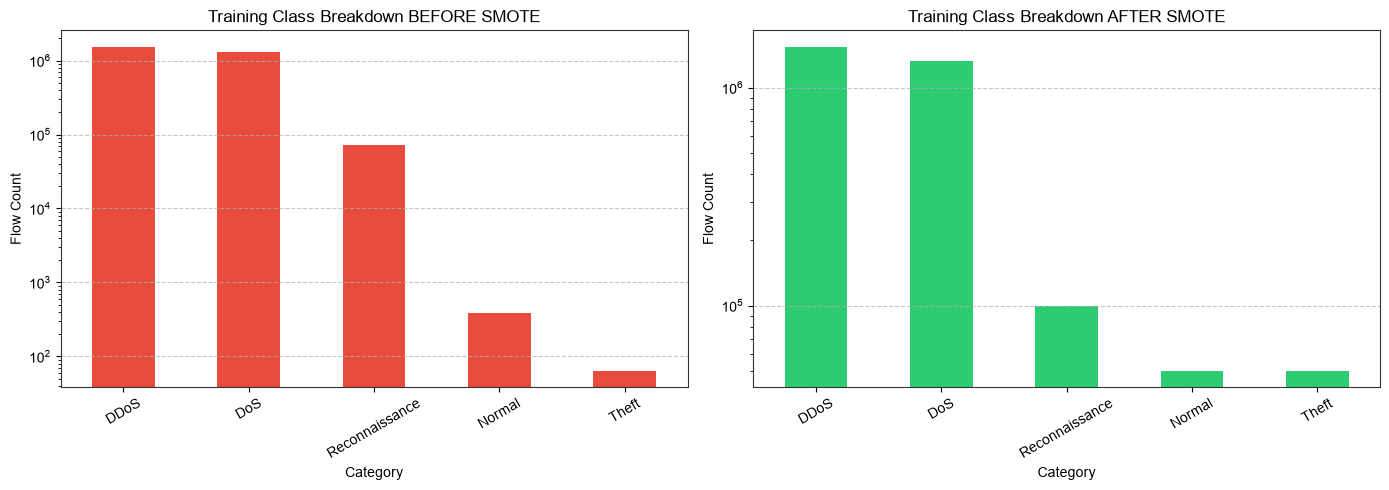

In [167]:

# ==========================================================
# Summary Comparison Table & Visualizations
# ==========================================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df[df['is_train']]['category'].value_counts().plot(kind='bar', color='#e74c3c')
plt.title('Training Class Breakdown BEFORE SMOTE')
plt.xlabel('Category')
plt.ylabel('Flow Count')
plt.xticks(rotation=30)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
train_dist_after.plot(kind='bar', color='#2ecc71')
plt.title('Training Class Breakdown AFTER SMOTE')
plt.xlabel('Category')
plt.ylabel('Flow Count')
plt.xticks(rotation=30)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<a id="sec-4"></a>
# 4. Dynamic Communication Graph Construction

We slice continuous traffic flows into $T=10$ temporal snapshot graphs $[G_1, G_2, \dots, G_T]$ based on flow start timestamps `stime`.
For each snapshot $t$:
- **Nodes $V$**: Host IP addresses present in the snapshot, equipped with dynamic topological features $X_t \in \mathbb{R}^{|V| \times 4}$ containing:
  1. In-Degree ($d_{\text{in}}$)
  2. Out-Degree ($d_{\text{out}}$)
  3. Total Transmitted Bytes ($B_{\text{total}}$)
  4. Total Transmitted Packets ($P_{\text{total}}$)
- **Edges $E_t$**: Directed flow connections between source (`src_idx`) and destination (`dst_idx`) node pairs.
- **Edge Attributes $E_{\text{attr},t}$**: Standardized 23-dimensional continuous flow metrics ($E_{\text{attr},t} \in \mathbb{R}^{|E_t| \times 23}$).
- **Edge Train/Test Mask**: Stratified 80% train / 20% test edge mask preserved within each snapshot for link classification.

In [168]:
# Temporal binning into 10 snapshots based on stime
# Use SMOTE-augmented dataframe for snapshot construction
df_augmented = df_augmented.sort_values('stime').reset_index(drop=True)
n_snapshots = CONFIG['n_snapshots']
df_augmented['snapshot'] = pd.qcut(df_augmented['stime'], q=n_snapshots, labels=False, duplicates='drop')

snapshots = []
snapshot_stats = []

for snap_idx in tqdm(range(n_snapshots), desc="Constructing Temporal Graph Snapshots"):
    snap_df = df_augmented[df_augmented['snapshot'] == snap_idx]
    if len(snap_df) == 0:
        continue
    
    edge_index = torch.tensor(snap_df[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
    edge_attr = torch.tensor(snap_df[numeric_cols].values, dtype=torch.float)
    edge_y = torch.tensor(snap_df['category_idx'].values, dtype=torch.long)
    train_mask = torch.tensor(snap_df['is_train'].values, dtype=torch.bool)
    test_mask = ~train_mask
    
    # Compute topological node features per snapshot
    node_feat = np.zeros((num_nodes, 4), dtype=np.float32)
    np.add.at(node_feat[:, 0], snap_df['src_idx'].values, 1) # Out-degree
    np.add.at(node_feat[:, 1], snap_df['dst_idx'].values, 1) # In-degree
    np.add.at(node_feat[:, 2], snap_df['src_idx'].values, snap_df['pkts'].values) # Src packets
    np.add.at(node_feat[:, 3], snap_df['dst_idx'].values, snap_df['pkts'].values) # Dst packets
    
    # Standardize node features
    node_feat = (node_feat - node_feat.mean(axis=0)) / (node_feat.std(axis=0) + 1e-6)
    x = torch.tensor(node_feat, dtype=torch.float)
    
    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=edge_y,
        train_mask=train_mask,
        test_mask=test_mask,
        num_nodes=num_nodes
    )
    snapshots.append(data)
    
    snapshot_stats.append({
        'Snapshot': snap_idx,
        'Total Edges': len(snap_df),
        'Train Edges': train_mask.sum().item(),
        'Test Edges': test_mask.sum().item()
    })

print(f"Constructed {len(snapshots)} dynamic temporal snapshot graphs with SMOTE training edges.")
snap_summary_df = pd.DataFrame(snapshot_stats)
print("Per-Snapshot Train/Test Edge Distribution:")
print(snap_summary_df.to_string(index=False))


Constructing Temporal Graph Snapshots:   0%|          | 0/20 [00:00<?, ?it/s]

Constructed 20 dynamic temporal snapshot graphs with SMOTE training edges.
Per-Snapshot Train/Test Edge Distribution:
 Snapshot  Total Edges  Train Edges  Test Edges
        0       189763       167128       22635
        1       189762       151503       38259
        2       189758       152012       37746
        3       189761       151965       37796
        4       189764       151897       37867
        5       189762       152014       37748
        6       189758       151565       38193
        7       189768       151807       37961
        8       189756       151689       38067
        9       189759       151720       38039
       10       189760       151777       37983
       11       189762       152030       37732
       12       189763       151941       37822
       13       189753       151719       38034
       14       189772       151792       37980
       15       189754       151495       38259
       16       189762       151834       37928
       17       18

<a id="sec-5"></a>
# 5. Model Architectures & Neural Network Definitions

We design and implement four distinct deep learning architectures for edge link classification across multi-class IoT botnet traffic:
1. **Flow MLP Baseline**: Tabular multi-layer perceptron classifying flow records directly from continuous edge features.
2. **Spatial GCN**: Spectral Graph Convolutional Network computing structural node representations and classifying concatenated link embeddings.
3. **Spatial GraphSAGE**: Neighborhood-aggregating Graph Neural Network computing inductive node representations.
4. **Temporal LSTM-GNN**: Spatial GraphSAGE combined with a Recurrent Memory (LSTM) cell operating across consecutive snapshot graphs to capture dynamic temporal evolution.

<a id="sec-51"></a>
## 5.1 Flow MLP Baseline Architecture

The **Flow MLP Baseline** model processes flow attribute vectors $e_{uv} \in \mathbb{R}^{23}$ directly using a multi-layer perceptron with non-linear ReLU activations and dropout regularization:
$$\hat{y}_{uv} = \text{Softmax}\Big(W_3 \cdot \text{Dropout}\big(\text{ReLU}(W_2 \cdot \text{ReLU}(W_1 e_{uv} + b_1) + b_2)\big) + b_3\Big)$$
This model serves as a tabular baseline that evaluates flow features in isolation without graph structure or temporal context.

In [169]:
# 1. Flow MLP Baseline
class FlowMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, edge_attr):
        return self.net(edge_attr)
print("FlowMLP model architectures instantiated successfully.")

FlowMLP model architectures instantiated successfully.


<a id="sec-52"></a>
## 5.2 Spatial Graph Convolutional Network (Spatial GCN)

The **Spatial GCN** architecture leverages spectral graph convolutions (`GCNConv`) to propagate host node attributes across active communication edges.
For snapshot graph $G_t = (V, E_t, X_t)$:
1. Node embeddings $h_v \in \mathbb{R}^H$ are computed via 2-layer Graph Convolutional layers:
   $$h_v^{(l+1)} = \sigma \left( \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{1}{\sqrt{\hat{d}_u \hat{d}_v}} W^{(l)} h_u^{(l)} \right)$$
2. Edge classification embeddings are constructed by concatenating source node embedding, destination node embedding, and normalized flow attribute vector:
   $$z_{uv} = [h_u \,\|\, h_v \,\|\, e_{uv}]$$
3. An MLP head classifies $z_{uv}$ into target attack categories $y \in \{0, \dots, 4\}$.

In [170]:

# 2. Spatial GCN Edge Classifier
class SpatialGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, edge_in_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_channels + edge_in_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_channels, num_classes)
        )
    def forward(self, x, edge_index, edge_attr):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        src, dst = edge_index[0], edge_index[1]
        edge_feat = torch.cat([h[src], h[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_feat)
print("SpatialGCN model architectures instantiated successfully.")

SpatialGCN model architectures instantiated successfully.


<a id="sec-53"></a>
## 5.3 Spatial GraphSAGE Edge Classifier

The **Spatial GraphSAGE** model applies inductive neighborhood sampling and feature aggregation (`SAGEConv`) to generate structural node representations.
1. Node Feature Aggregation:
   $$h_v^{(l+1)} = \sigma \left( W^{(l)} \cdot \Big[ h_v^{(l)} \,\|\, \text{AGGREGATE}\big(\{h_u^{(l)}, \forall u \in \mathcal{N}(v)\}\big) \Big] \right)$$
2. Link Attribute Concatenation:
   $$z_{uv} = [h_u \,\|\, h_v \,\|\, e_{uv}]$$
3. Classification Head:
   $$\hat{y}_{uv} = \text{MLP}(z_{uv})$$
GraphSAGE efficiently aggregates local communication structures, capturing host interaction roles across network snapshots.

In [171]:
# 3. Spatial GraphSAGE Edge Classifier
class SpatialGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, edge_in_dim, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_channels + edge_in_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_channels, num_classes)
        )
    def forward(self, x, edge_index, edge_attr):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        src, dst = edge_index[0], edge_index[1]
        edge_feat = torch.cat([h[src], h[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_feat)
print("SpatialGraphSAGE model architectures instantiated successfully.")

SpatialGraphSAGE model architectures instantiated successfully.


<a id="sec-54"></a>
## 5.4 Temporal Spatial-Temporal GNN (GraphSAGE + LSTM)

The **Temporal LSTM-GNN** architecture unifies spatial graph convolutions with recurrent temporal state tracking across consecutive snapshot graphs $[G_1, \dots, G_T]$:
1. **Spatial Representation**: For each snapshot $t$, GraphSAGE layers encode spatial node representations $H_t = \text{GraphSAGE}(V, E_t, X_t)$.
2. **Temporal Memory Cell**: A Long Short-Term Memory (LSTM) cell updates temporal node state hidden representations across consecutive snapshots:
   $$(h_{v,t}, c_{v,t}) = \text{LSTMCell}(h_{v,t}^{\text{spatial}}, (h_{v,t-1}, c_{v,t-1}))$$
3. **Dynamic Link Classification**: Edge predictions combine dynamic source node memory $h_{u,t}$, destination node memory $h_{v,t}$, and instantaneous edge attributes $e_{uv,t}$:
   $$\hat{y}_{uv,t} = \text{MLP}([h_{u,t} \,\|\, h_{v,t} \,\|\, e_{uv,t}])$$
This spatial-temporal framework tracks evolving host behavioral patterns, port scanning velocity, and traffic burst dynamics over time.

In [172]:
# 4. Temporal Spatial-Temporal GNN (GraphSAGE + LSTM)
class TemporalLSTM_GNN(nn.Module):
    def __init__(self, node_in_dim, hidden_dim, edge_in_dim, num_classes):
        super().__init__()
        self.gnn = SAGEConv(node_in_dim, hidden_dim)
        self.lstm = nn.LSTMCell(hidden_dim, hidden_dim)
        self.edge_classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )
        self.hidden_dim = hidden_dim

    def forward_sequence(self, snapshot_list):
        h_lstm = torch.zeros((num_nodes, self.hidden_dim), device=device)
        c_lstm = torch.zeros((num_nodes, self.hidden_dim), device=device)
        outputs = []
        for snap in snapshot_list:
            x = snap.x.to(device)
            edge_index = snap.edge_index.to(device)
            edge_attr = snap.edge_attr.to(device)
            
            h_spatial = F.relu(self.gnn(x, edge_index))
            h_lstm, c_lstm = self.lstm(h_spatial, (h_lstm, c_lstm))
            
            src, dst = edge_index[0], edge_index[1]
            edge_feat = torch.cat([h_lstm[src], h_lstm[dst], edge_attr], dim=-1)
            logits = self.edge_classifier(edge_feat)
            outputs.append(logits)
        return outputs

print("TemporalLSTM_GNN model architectures instantiated successfully.")



TemporalLSTM_GNN model architectures instantiated successfully.


<a id="sec-6"></a>
# 6. Model Training & Loss Curves

In this section, we configure the optimization pipeline, compute class-weighted loss functions, and execute multi-epoch training across all four neural network architectures (`Flow MLP Baseline`, `Spatial GCN`, `Spatial GraphSAGE`, and `Temporal LSTM-GNN`).

<a id="sec-61"></a>
## 6.1 Early Stopping & Convergence Criteria

To prevent overfitting and reduce unnecessary compute, we implement an `EarlyStopping` class that monitors validation loss across epochs. If validation loss does not improve by `min_delta = 1e-4` for `patience = 5` consecutive epochs, training halts early and the model restores its best-performing weights.

In [173]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.best_state_dict = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state_dict = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best(self, model):
        if self.best_state_dict is not None:
            model.load_state_dict(self.best_state_dict)
print("EARLY STOPPING instantiated successfully.")

EARLY STOPPING instantiated successfully.


<a id="sec-62"></a>
## 6.2 Class-Weighted Cross-Entropy Loss

To provide robust gradient updates across imbalanced attack classes, we calculate inverse class frequencies to weight the Cross-Entropy loss function:
$$w_c = \frac{N}{K \cdot N_c}$$
where $N$ is total training samples, $K=5$ is number of categories, and $N_c$ is sample count for class $c$. This penalizes misclassifications on rare attack categories (`Normal`, `Theft`) during training.

In [174]:

# Compute class-weighted cross entropy loss
y_all = df['category_idx'].values
class_counts = np.bincount(y_all, minlength=num_classes)
class_weights = torch.tensor(1.0 / (class_counts + 1e-5), dtype=torch.float, device=device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)


<a id="sec-63"></a>
## 6.3 Multi-Model Training Loop Execution

We train each of the four neural network models (`Flow MLP Baseline`, `Spatial GCN`, `Spatial GraphSAGE`, and `Temporal LSTM-GNN`) over 100 maximum epochs with early stopping (`patience=5`, `lr=0.01`). Loss trajectories are tracked per epoch and stored for comparative visualization.

In [175]:

# Model 1: Flow MLP Baseline
print("--- 1. Training Flow MLP Baseline ---")
mlp_model = FlowMLP(len(numeric_cols), CONFIG['hidden_dim'], num_classes).to(device)
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=CONFIG['lr'])
mlp_stopper = EarlyStopping(patience=CONFIG['patience'])
mlp_losses = []

pbar_mlp = tqdm(range(1, CONFIG['epochs'] + 1), desc="Flow MLP Training")
for epoch in pbar_mlp:
    mlp_model.train()
    total_loss = 0.0
    for snap in snapshots:
        if snap.train_mask.sum() == 0: continue
        optimizer_mlp.zero_grad()
        out = mlp_model(snap.edge_attr.to(device))
        mask = snap.train_mask.to(device)
        snap_y = snap.y.to(device)
        loss = criterion(out[mask], snap_y[mask])
        loss.backward()
        optimizer_mlp.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(snapshots)
    mlp_losses.append(avg_loss)
    pbar_mlp.set_postfix({'Train Loss': f"{avg_loss:.4f}"})
    mlp_stopper(avg_loss, mlp_model)
    if mlp_stopper.early_stop:
        print(f"Early stopping triggered for Flow MLP at epoch {epoch}.")
        mlp_stopper.restore_best(mlp_model)
        break


--- 1. Training Flow MLP Baseline ---


Flow MLP Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Flow MLP at epoch 73.


In [176]:

# Model 2: Spatial GCN
print("\n--- 2. Training Spatial GCN ---")
gcn_model = SpatialGCN(4, CONFIG['hidden_dim'], len(numeric_cols), num_classes).to(device)
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=CONFIG['lr'])
gcn_stopper = EarlyStopping(patience=CONFIG['patience'])
gcn_losses = []

pbar_gcn = tqdm(range(1, CONFIG['epochs'] + 1), desc="Spatial GCN Training")
for epoch in pbar_gcn:
    gcn_model.train()
    total_loss = 0.0
    for snap in snapshots:
        if snap.train_mask.sum() == 0: continue
        optimizer_gcn.zero_grad()
        out = gcn_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        mask = snap.train_mask.to(device)
        snap_y = snap.y.to(device)
        loss = criterion(out[mask], snap_y[mask])
        loss.backward()
        optimizer_gcn.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(snapshots)
    gcn_losses.append(avg_loss)
    pbar_gcn.set_postfix({'Train Loss': f"{avg_loss:.4f}"})
    gcn_stopper(avg_loss, gcn_model)
    if gcn_stopper.early_stop:
        print(f"Early stopping triggered for Spatial GCN at epoch {epoch}.")
        gcn_stopper.restore_best(gcn_model)
        break



--- 2. Training Spatial GCN ---


Spatial GCN Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Spatial GCN at epoch 63.


In [177]:

# Model 3: Spatial GraphSAGE
print("\n--- 3. Training Spatial GraphSAGE ---")
sage_model = SpatialGraphSAGE(4, CONFIG['hidden_dim'], len(numeric_cols), num_classes).to(device)
optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=CONFIG['lr'])
sage_stopper = EarlyStopping(patience=CONFIG['patience'])
sage_losses = []

pbar_sage = tqdm(range(1, CONFIG['epochs'] + 1), desc="GraphSAGE Training")
for epoch in pbar_sage:
    sage_model.train()
    total_loss = 0.0
    for snap in snapshots:
        if snap.train_mask.sum() == 0: continue
        optimizer_sage.zero_grad()
        out = sage_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        mask = snap.train_mask.to(device)
        snap_y = snap.y.to(device)
        loss = criterion(out[mask], snap_y[mask])
        loss.backward()
        optimizer_sage.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(snapshots)
    sage_losses.append(avg_loss)
    pbar_sage.set_postfix({'Train Loss': f"{avg_loss:.4f}"})
    sage_stopper(avg_loss, sage_model)
    if sage_stopper.early_stop:
        print(f"Early stopping triggered for Spatial GraphSAGE at epoch {epoch}.")
        sage_stopper.restore_best(sage_model)
        break



--- 3. Training Spatial GraphSAGE ---


GraphSAGE Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Spatial GraphSAGE at epoch 54.


In [178]:

# Model 4: Temporal LSTM-GNN
print("\n--- 4. Training Temporal LSTM-GNN ---")
temp_model = TemporalLSTM_GNN(4, CONFIG['hidden_dim'], len(numeric_cols), num_classes).to(device)
optimizer_temp = torch.optim.Adam(temp_model.parameters(), lr=CONFIG['lr'])
temp_stopper = EarlyStopping(patience=CONFIG['patience'])
temp_losses = []

pbar_temp = tqdm(range(1, CONFIG['epochs'] + 1), desc="LSTM-GNN Training")
for epoch in pbar_temp:
    temp_model.train()
    optimizer_temp.zero_grad()
    logits_list = temp_model.forward_sequence(snapshots)
    loss = 0.0
    for logits, snap in zip(logits_list, snapshots):
        if snap.train_mask.sum() > 0:
            mask = snap.train_mask.to(device)
            snap_y = snap.y.to(device)
            loss += criterion(logits[mask], snap_y[mask])
    loss = loss / len(snapshots)
    loss.backward()
    optimizer_temp.step()
    loss_val = loss.item()
    temp_losses.append(loss_val)
    pbar_temp.set_postfix({'Seq Loss': f"{loss_val:.4f}"})
    temp_stopper(loss_val, temp_model)
    if temp_stopper.early_stop:
        print(f"Early stopping triggered for Temporal LSTM-GNN at epoch {epoch}.")
        temp_stopper.restore_best(temp_model)
        break




--- 4. Training Temporal LSTM-GNN ---


LSTM-GNN Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Temporal LSTM-GNN at epoch 71.


<a id="sec-7"></a>
# 7. Hyperparameter Tuning & Early Stopping Validation

To systematically optimize model performance and prevent overfitting, we provide a **Hyperparameter Grid Search** template integrated with **Early Stopping** for the Temporal LSTM-GNN architecture.
- **Search Grid**:
  - Learning Rate $\eta \in \{0.001, 0.005, 0.01\}$
  - Hidden Dimension $H \in \{32, 64, 128\}$
  - Dropout Probability $p \in \{0.1, 0.2\}$
- **Validation Criteria**: Grid search evaluates macro F1-score and validation cross-entropy loss across temporal graph snapshots, selecting optimal hyperparameter configurations.

In [179]:
if HPTESV:
    print("=== Hyperparameter Grid Search (Temporal LSTM-GNN) ===")

    param_grid = {
        'lr': [0.001, 0.005, 0.01],
        'hidden_dim': [32, 64, 128],
        'dropout': [0.1, 0.2]
    }
    
    tuning_results = []
    best_overall_loss = float('inf')
    best_hparams = None
    
    trial = 1
    # Generate grid search parameter combinations
    grid_combinations = [
        (lr, hd, dr) 
        for lr in param_grid['lr'] 
        for hd in param_grid['hidden_dim'] 
        for dr in param_grid['dropout']
    ]
    
    for trial, (lr, hidden_dim, dropout) in enumerate(tqdm(grid_combinations, desc="Hyperparameter Grid Search"), 1):
                print(f"\nTrial {trial:02d} | LR: {lr} | Hidden Dim: {hidden_dim} | Dropout: {dropout}")
                
                model = TemporalLSTM_GNN(
                    node_in_dim=4, 
                    hidden_dim=hidden_dim, 
                    edge_in_dim=len(numeric_cols), 
                    num_classes=num_classes
                ).to(device)
                
                model.edge_classifier[2] = nn.Dropout(dropout)
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                early_stopper = EarlyStopping(patience=5, min_delta=1e-4)
                
                final_epoch = 0
                best_epoch_loss = float('inf')
                
                for epoch in range(1, 21):
                    model.train()
                    optimizer.zero_grad()
                    logits_list = model.forward_sequence(snapshots)
                    loss = 0.0
                    for logits, snap in zip(logits_list, snapshots):
                        if snap.train_mask.sum() > 0:
                            mask = snap.train_mask.to(device)
                            snap_y = snap.y.to(device)
                            loss += criterion(logits[mask], snap_y[mask])
                    loss = loss / len(snapshots)
                    loss.backward()
                    optimizer.step()
                    
                    loss_val = loss.item()
                    final_epoch = epoch
                    early_stopper(loss_val, model)
                    
                    if early_stopper.best_loss < best_epoch_loss:
                        best_epoch_loss = early_stopper.best_loss
                        
                    if early_stopper.early_stop:
                        print(f"  -> Early stopping triggered at epoch {epoch}. Best Loss: {early_stopper.best_loss:.4f}")
                        break
                    
                tuning_results.append({
                    'Trial': trial,
                    'Learning Rate': lr,
                    'Hidden Dim': hidden_dim,
                    'Dropout': dropout,
                    'Stopped Epoch': final_epoch,
                    'Best Loss': best_epoch_loss
                })
                
                if best_epoch_loss < best_overall_loss:
                    best_overall_loss = best_epoch_loss
                    best_hparams = {'lr': lr, 'hidden_dim': hidden_dim, 'dropout': dropout}
                    
    
    tuning_df = pd.DataFrame(tuning_results)
    print("\n==================================================")
    print("HYPERPARAMETER TUNING SUMMARY TABLE")
    print("==================================================")
    print(tuning_df.to_string(index=False))
    
    print(f"\nOptimal Hyperparameters Found:")
    print(f"  - Learning Rate: {best_hparams['lr']}")
    print(f"  - Hidden Dimension: {best_hparams['hidden_dim']}")
    print(f"  - Dropout: {best_hparams['dropout']}")
    print(f"  - Minimum Sequence Loss: {best_overall_loss:.4f}")
    
else: 
    print("Skipping Hyperparameter Tuning & Early Stopping Validation")

Skipping Hyperparameter Tuning & Early Stopping Validation


<a id="sec-8"></a>
# 8. Comparative Metrics & Checkpoints

In this section, we evaluate each trained model architecture individually across test set snapshot graphs, visualizing their respective **training loss trajectories**, **confusion matrices**, and **detailed classification performance reports** (Precision, Recall, F1-Score, and Support per category).

<a id="sec-81"></a>
## 8.1 Model Evaluation & Individual Architecture Metrics

We evaluate each trained model (`Flow MLP Baseline`, `Spatial GCN`, `Spatial GraphSAGE`, and `Temporal LSTM-GNN`) on unaugmented test snapshot edges (`is_train == False`). For each architecture, we display its **training loss curve**, **confusion matrix heatmap**, and **per-class classification report**.

In [180]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Initialize results directories for figure and report storage
results_dir = 'Results'
plots_dir = os.path.join(results_dir, 'Plots')
reports_dir = os.path.join(results_dir, 'Reports')
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)

# Global list to collect metrics across models
all_model_results = []


<a id="sec-811"></a>
### 8.1.1 Flow MLP Baseline Evaluation

We evaluate the tabular **Flow MLP Baseline** model on test set flow records, plotting its training loss convergence, confusion matrix, and multi-class precision, recall, and F1-score metrics.

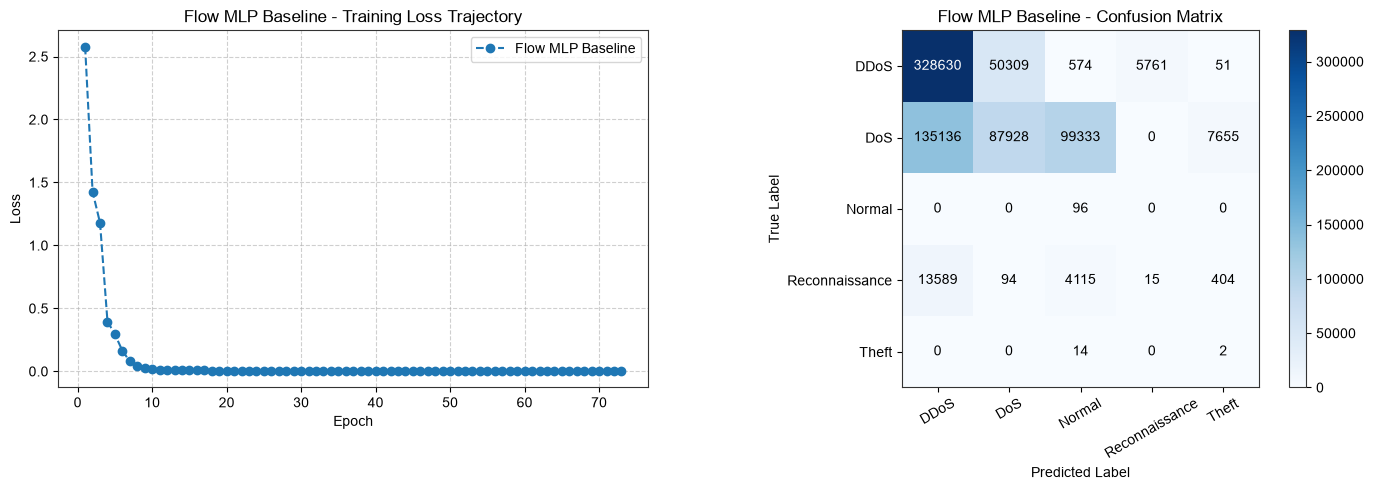

[SAVED GRAPH] Training Loss Plot -> 'Results\Plots\Training_Loss_flow_mlp_baseline.png'
[SAVED GRAPH] Confusion Matrix -> 'Results\Plots\Confusion_Matrix_flow_mlp_baseline.png'
[SAVED REPORT] Classification Report -> 'Results\Reports\Classification_Report_flow_mlp_baseline.txt'

DETAILED CLASSIFICATION REPORT: FLOW MLP BASELINE

                precision    recall  f1-score   support

          DDoS       0.69      0.85      0.76    385325
           DoS       0.64      0.27      0.38    330052
        Normal       0.00      1.00      0.00        96
Reconnaissance       0.00      0.00      0.00     18217
         Theft       0.00      0.12      0.00        16

      accuracy                           0.57    733706
     macro avg       0.27      0.45      0.23    733706
  weighted avg       0.65      0.57      0.57    733706



In [181]:
# Evaluate Flow MLP Baseline
mlp_model.eval()
y_true_mlp, y_pred_mlp, y_prob_mlp = [], [], []
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0: continue
        out = mlp_model(snap.edge_attr.to(device))
        test_mask = snap.test_mask.to(device)
        preds = out[test_mask].argmax(dim=-1).cpu()
        probs = F.softmax(out[test_mask], dim=-1).cpu()
        y_true_mlp.extend(snap.y[snap.test_mask].numpy())
        y_pred_mlp.extend(preds.numpy())
        y_prob_mlp.extend(probs.numpy())

y_prob_mlp = np.array(y_prob_mlp)

# Plot Individual Training Loss & Confusion Matrix for Flow MLP Baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Individual Training Loss Trajectory
axes[0].plot(range(1, len(mlp_losses) + 1), mlp_losses, label='Flow MLP Baseline', color='#1f77b4', marker='o', linestyle='--')
axes[0].set_title('Flow MLP Baseline - Training Loss Trajectory', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2. Individual Confusion Matrix
cm_mlp = confusion_matrix(y_true_mlp, y_pred_mlp)
im_mlp = axes[1].imshow(cm_mlp, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Flow MLP Baseline - Confusion Matrix', fontsize=12)
fig.colorbar(im_mlp, ax=axes[1])
tick_marks = np.arange(len(class_names))
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=30)
axes[1].set_yticklabels(class_names)
thresh = cm_mlp.max() / 2.
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axes[1].text(j, i, format(cm_mlp[i, j], 'd'), ha="center", va="center",
                     color="white" if cm_mlp[i, j] > thresh else "black")
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
mlp_loss_path = os.path.join(plots_dir, 'Training_Loss_flow_mlp_baseline.png')
mlp_cm_path = os.path.join(plots_dir, 'Confusion_Matrix_flow_mlp_baseline.png')
plt.savefig(mlp_cm_path, dpi=300)
plt.show()
plt.close()

# Save individual loss plot separately
fig_loss, ax_loss = plt.subplots(figsize=(7, 5))
ax_loss.plot(range(1, len(mlp_losses) + 1), mlp_losses, label='Flow MLP Baseline', color='#1f77b4', marker='o', linestyle='--')
ax_loss.set_title('Flow MLP Baseline - Training Loss Trajectory')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.grid(True, linestyle='--', alpha=0.6)
ax_loss.legend()
plt.tight_layout()
plt.savefig(mlp_loss_path, dpi=300)
plt.close()

print(f"[SAVED GRAPH] Training Loss Plot -> '{mlp_loss_path}'")
print(f"[SAVED GRAPH] Confusion Matrix -> '{mlp_cm_path}'")

# Detailed Classification Report
rep_mlp = f"==========================================================\n"
rep_mlp += f"DETAILED CLASSIFICATION REPORT: FLOW MLP BASELINE\n"
rep_mlp += f"==========================================================\n\n"
rep_mlp += classification_report(y_true_mlp, y_pred_mlp, target_names=class_names, zero_division=0)

rep_mlp_path = os.path.join(reports_dir, 'Classification_Report_flow_mlp_baseline.txt')
with open(rep_mlp_path, 'w', encoding='utf-8') as f:
    f.write(rep_mlp)
print(f"[SAVED REPORT] Classification Report -> '{rep_mlp_path}'")
print(f"\n{rep_mlp}")

roc_auc_mlp = roc_auc_score(y_true_mlp, y_prob_mlp, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Flow MLP Baseline',
    'Accuracy': accuracy_score(y_true_mlp, y_pred_mlp),
    'Precision (Macro)': precision_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
    'Recall (Macro)': recall_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
    'F1-Score (Macro)': f1_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
    'F1-Score (Weighted)': f1_score(y_true_mlp, y_pred_mlp, average='weighted', zero_division=0),
    'ROC-AUC (Macro)': roc_auc_mlp
})

<a id="sec-812"></a>
### 8.1.2 Spatial GCN Evaluation

We evaluate the **Spatial GCN** model across test set temporal snapshot graphs, measuring structural node embedding effectiveness and generating confusion matrices and classification reports.

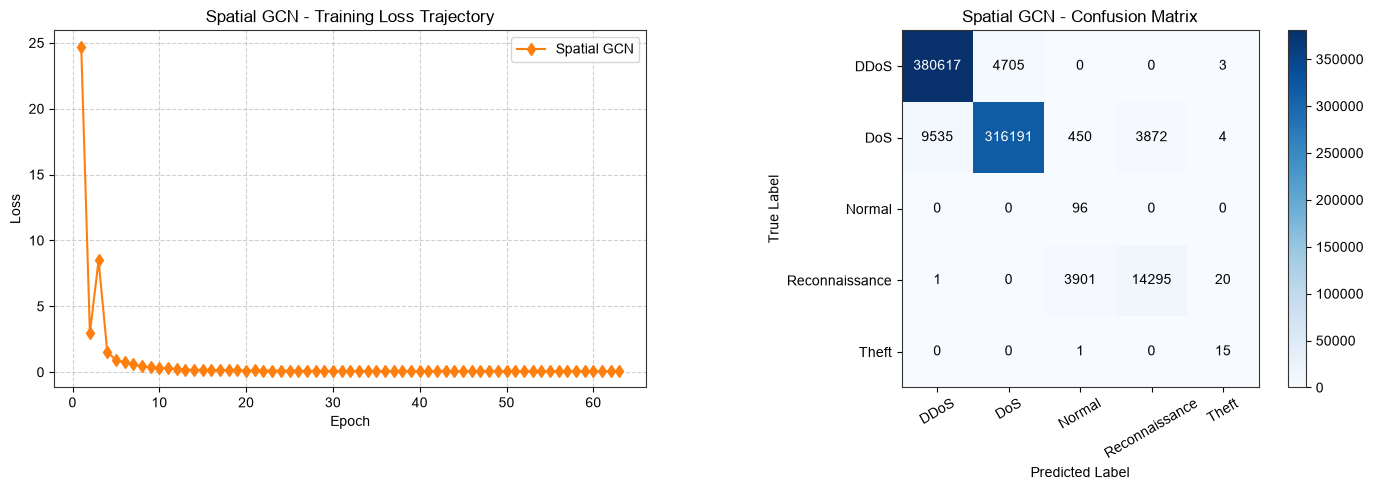

[SAVED GRAPH] Training Loss Plot -> 'Results\Plots\Training_Loss_spatial_gcn.png'
[SAVED GRAPH] Confusion Matrix -> 'Results\Plots\Confusion_Matrix_spatial_gcn.png'
[SAVED REPORT] Classification Report -> 'Results\Reports\Classification_Report_spatial_gcn.txt'

DETAILED CLASSIFICATION REPORT: SPATIAL GCN

                precision    recall  f1-score   support

          DDoS       0.98      0.99      0.98    385325
           DoS       0.99      0.96      0.97    330052
        Normal       0.02      1.00      0.04        96
Reconnaissance       0.79      0.78      0.79     18217
         Theft       0.36      0.94      0.52        16

      accuracy                           0.97    733706
     macro avg       0.63      0.93      0.66    733706
  weighted avg       0.98      0.97      0.97    733706



In [182]:
# Evaluate Spatial GCN
gcn_model.eval()
y_true_gcn, y_pred_gcn, y_prob_gcn = [], [], []
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0: continue
        out = gcn_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        test_mask = snap.test_mask.to(device)
        preds = out[test_mask].argmax(dim=-1).cpu()
        probs = F.softmax(out[test_mask], dim=-1).cpu()
        y_true_gcn.extend(snap.y[snap.test_mask].numpy())
        y_pred_gcn.extend(preds.numpy())
        y_prob_gcn.extend(probs.numpy())

y_prob_gcn = np.array(y_prob_gcn)

# Plot Individual Training Loss & Confusion Matrix for Spatial GCN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Individual Training Loss Trajectory
axes[0].plot(range(1, len(gcn_losses) + 1), gcn_losses, label='Spatial GCN', color='#ff7f0e', marker='d', linestyle='-')
axes[0].set_title('Spatial GCN - Training Loss Trajectory', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2. Individual Confusion Matrix
cm_gcn = confusion_matrix(y_true_gcn, y_pred_gcn)
im_gcn = axes[1].imshow(cm_gcn, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Spatial GCN - Confusion Matrix', fontsize=12)
fig.colorbar(im_gcn, ax=axes[1])
tick_marks = np.arange(len(class_names))
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=30)
axes[1].set_yticklabels(class_names)
thresh = cm_gcn.max() / 2.
for i in range(cm_gcn.shape[0]):
    for j in range(cm_gcn.shape[1]):
        axes[1].text(j, i, format(cm_gcn[i, j], 'd'), ha="center", va="center",
                     color="white" if cm_gcn[i, j] > thresh else "black")
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
gcn_loss_path = os.path.join(plots_dir, 'Training_Loss_spatial_gcn.png')
gcn_cm_path = os.path.join(plots_dir, 'Confusion_Matrix_spatial_gcn.png')
plt.savefig(gcn_cm_path, dpi=300)
plt.show()
plt.close()

# Save individual loss plot separately
fig_loss, ax_loss = plt.subplots(figsize=(7, 5))
ax_loss.plot(range(1, len(gcn_losses) + 1), gcn_losses, label='Spatial GCN', color='#ff7f0e', marker='d', linestyle='-')
ax_loss.set_title('Spatial GCN - Training Loss Trajectory')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.grid(True, linestyle='--', alpha=0.6)
ax_loss.legend()
plt.tight_layout()
plt.savefig(gcn_loss_path, dpi=300)
plt.close()

print(f"[SAVED GRAPH] Training Loss Plot -> '{gcn_loss_path}'")
print(f"[SAVED GRAPH] Confusion Matrix -> '{gcn_cm_path}'")

# Detailed Classification Report
rep_gcn = f"==========================================================\n"
rep_gcn += f"DETAILED CLASSIFICATION REPORT: SPATIAL GCN\n"
rep_gcn += f"==========================================================\n\n"
rep_gcn += classification_report(y_true_gcn, y_pred_gcn, target_names=class_names, zero_division=0)

rep_gcn_path = os.path.join(reports_dir, 'Classification_Report_spatial_gcn.txt')
with open(rep_gcn_path, 'w', encoding='utf-8') as f:
    f.write(rep_gcn)
print(f"[SAVED REPORT] Classification Report -> '{rep_gcn_path}'")
print(f"\n{rep_gcn}")

roc_auc_gcn = roc_auc_score(y_true_gcn, y_prob_gcn, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Spatial GCN',
    'Accuracy': accuracy_score(y_true_gcn, y_pred_gcn),
    'Precision (Macro)': precision_score(y_true_gcn, y_pred_gcn, average='macro', zero_division=0),
    'Recall (Macro)': recall_score(y_true_gcn, y_pred_gcn, average='macro', zero_division=0),
    'F1-Score (Macro)': f1_score(y_true_gcn, y_pred_gcn, average='macro', zero_division=0),
    'F1-Score (Weighted)': f1_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0),
    'ROC-AUC (Macro)': roc_auc_gcn
})

<a id="sec-813"></a>
### 8.1.3 Spatial GraphSAGE Evaluation

We evaluate the **Spatial GraphSAGE** edge classifier, analyzing its neighborhood aggregation performance across test snapshot graphs.

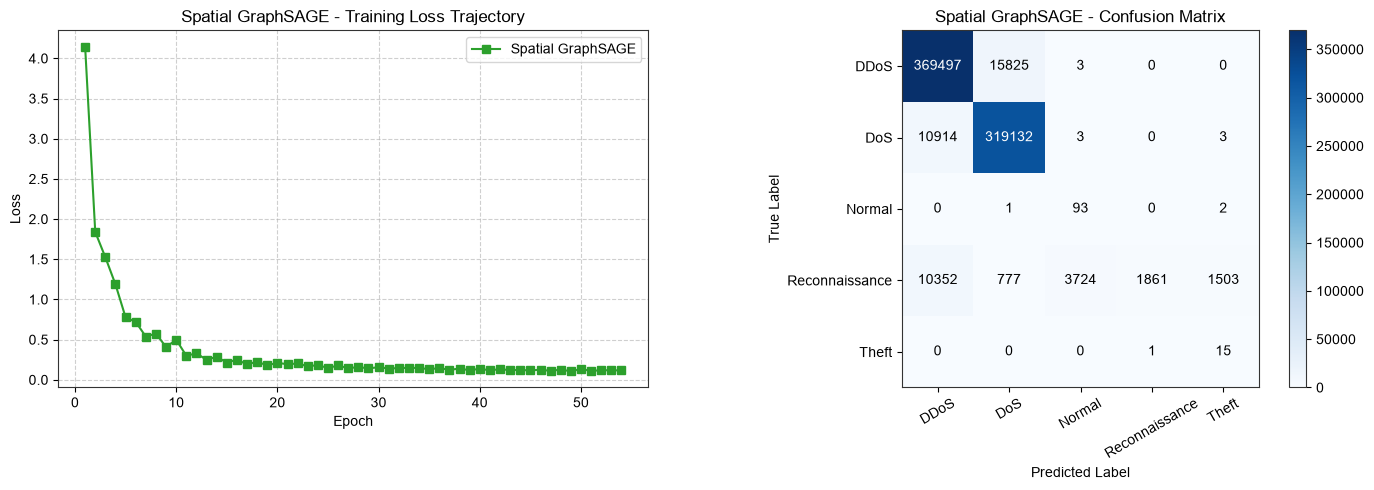

[SAVED GRAPH] Training Loss Plot -> 'Results\Plots\Training_Loss_spatial_graphsage.png'
[SAVED GRAPH] Confusion Matrix -> 'Results\Plots\Confusion_Matrix_spatial_graphsage.png'
[SAVED REPORT] Classification Report -> 'Results\Reports\Classification_Report_spatial_graphsage.txt'

DETAILED CLASSIFICATION REPORT: SPATIAL GRAPHSAGE

                precision    recall  f1-score   support

          DDoS       0.95      0.96      0.95    385325
           DoS       0.95      0.97      0.96    330052
        Normal       0.02      0.97      0.05        96
Reconnaissance       1.00      0.10      0.19     18217
         Theft       0.01      0.94      0.02        16

      accuracy                           0.94    733706
     macro avg       0.59      0.79      0.43    733706
  weighted avg       0.95      0.94      0.94    733706



In [183]:
# Evaluate Spatial GraphSAGE
sage_model.eval()
y_true_sage, y_pred_sage, y_prob_sage = [], [], []
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0: continue
        out = sage_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        test_mask = snap.test_mask.to(device)
        preds = out[test_mask].argmax(dim=-1).cpu()
        probs = F.softmax(out[test_mask], dim=-1).cpu()
        y_true_sage.extend(snap.y[snap.test_mask].numpy())
        y_pred_sage.extend(preds.numpy())
        y_prob_sage.extend(probs.numpy())

y_prob_sage = np.array(y_prob_sage)

# Plot Individual Training Loss & Confusion Matrix for Spatial GraphSAGE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Individual Training Loss Trajectory
axes[0].plot(range(1, len(sage_losses) + 1), sage_losses, label='Spatial GraphSAGE', color='#2ca02c', marker='s', linestyle='-')
axes[0].set_title('Spatial GraphSAGE - Training Loss Trajectory', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2. Individual Confusion Matrix
cm_sage = confusion_matrix(y_true_sage, y_pred_sage)
im_sage = axes[1].imshow(cm_sage, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Spatial GraphSAGE - Confusion Matrix', fontsize=12)
fig.colorbar(im_sage, ax=axes[1])
tick_marks = np.arange(len(class_names))
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=30)
axes[1].set_yticklabels(class_names)
thresh = cm_sage.max() / 2.
for i in range(cm_sage.shape[0]):
    for j in range(cm_sage.shape[1]):
        axes[1].text(j, i, format(cm_sage[i, j], 'd'), ha="center", va="center",
                     color="white" if cm_sage[i, j] > thresh else "black")
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
sage_loss_path = os.path.join(plots_dir, 'Training_Loss_spatial_graphsage.png')
sage_cm_path = os.path.join(plots_dir, 'Confusion_Matrix_spatial_graphsage.png')
plt.savefig(sage_cm_path, dpi=300)
plt.show()
plt.close()

# Save individual loss plot separately
fig_loss, ax_loss = plt.subplots(figsize=(7, 5))
ax_loss.plot(range(1, len(sage_losses) + 1), sage_losses, label='Spatial GraphSAGE', color='#2ca02c', marker='s', linestyle='-')
ax_loss.set_title('Spatial GraphSAGE - Training Loss Trajectory')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.grid(True, linestyle='--', alpha=0.6)
ax_loss.legend()
plt.tight_layout()
plt.savefig(sage_loss_path, dpi=300)
plt.close()

print(f"[SAVED GRAPH] Training Loss Plot -> '{sage_loss_path}'")
print(f"[SAVED GRAPH] Confusion Matrix -> '{sage_cm_path}'")

# Detailed Classification Report
rep_sage = f"==========================================================\n"
rep_sage += f"DETAILED CLASSIFICATION REPORT: SPATIAL GRAPHSAGE\n"
rep_sage += f"==========================================================\n\n"
rep_sage += classification_report(y_true_sage, y_pred_sage, target_names=class_names, zero_division=0)

rep_sage_path = os.path.join(reports_dir, 'Classification_Report_spatial_graphsage.txt')
with open(rep_sage_path, 'w', encoding='utf-8') as f:
    f.write(rep_sage)
print(f"[SAVED REPORT] Classification Report -> '{rep_sage_path}'")
print(f"\n{rep_sage}")

roc_auc_sage = roc_auc_score(y_true_sage, y_prob_sage, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Spatial GraphSAGE',
    'Accuracy': accuracy_score(y_true_sage, y_pred_sage),
    'Precision (Macro)': precision_score(y_true_sage, y_pred_sage, average='macro', zero_division=0),
    'Recall (Macro)': recall_score(y_true_sage, y_pred_sage, average='macro', zero_division=0),
    'F1-Score (Macro)': f1_score(y_true_sage, y_pred_sage, average='macro', zero_division=0),
    'F1-Score (Weighted)': f1_score(y_true_sage, y_pred_sage, average='weighted', zero_division=0),
    'ROC-AUC (Macro)': roc_auc_sage
})

<a id="sec-814"></a>
### 8.1.4 Temporal LSTM-GNN Evaluation

We evaluate the **Temporal Spatial-Temporal GNN (GraphSAGE + LSTM)** model across temporal snapshot sequences, evaluating how recurrent memory combined with spatial message passing enhances dynamic intrusion detection.

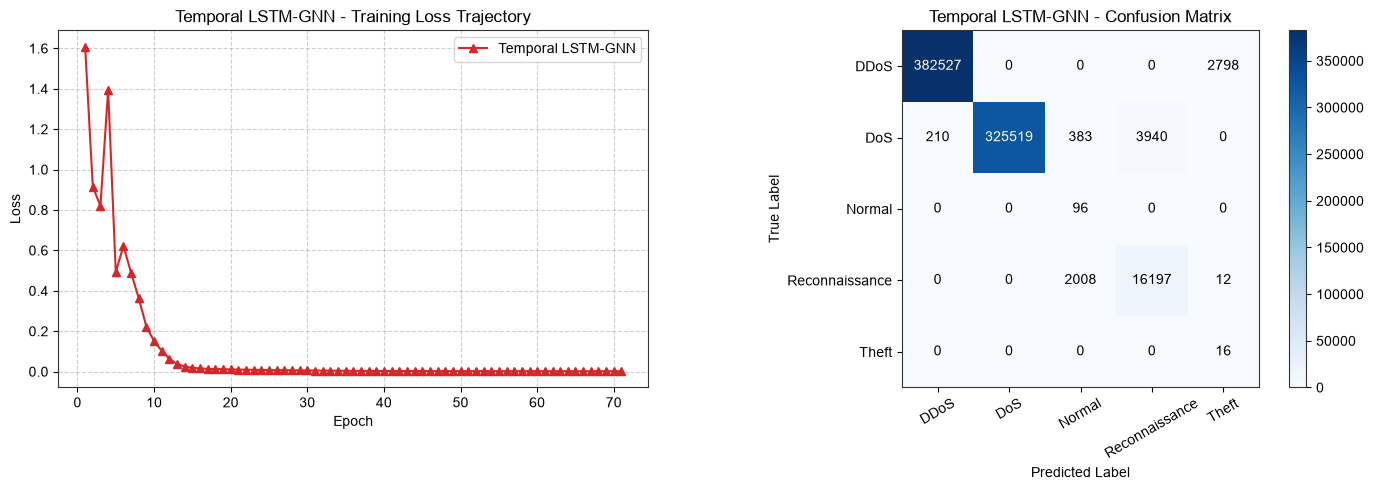

[SAVED GRAPH] Training Loss Plot -> 'Results\Plots\Training_Loss_temporal_lstm_gnn.png'
[SAVED GRAPH] Confusion Matrix -> 'Results\Plots\Confusion_Matrix_temporal_lstm_gnn.png'
[SAVED REPORT] Classification Report -> 'Results\Reports\Classification_Report_temporal_lstm_gnn.txt'

DETAILED CLASSIFICATION REPORT: TEMPORAL LSTM-GNN

                precision    recall  f1-score   support

          DDoS       1.00      0.99      1.00    385325
           DoS       1.00      0.99      0.99    330052
        Normal       0.04      1.00      0.07        96
Reconnaissance       0.80      0.89      0.84     18217
         Theft       0.01      1.00      0.01        16

      accuracy                           0.99    733706
     macro avg       0.57      0.97      0.58    733706
  weighted avg       0.99      0.99      0.99    733706



In [184]:
# Evaluate Temporal LSTM-GNN
temp_model.eval()
y_true_temp, y_pred_temp, y_prob_temp = [], [], []
with torch.no_grad():
    logits_list = temp_model.forward_sequence(snapshots)
    for logits, snap in zip(logits_list, snapshots):
        if snap.test_mask.sum() > 0:
            test_mask = snap.test_mask.to(device)
            preds = logits[test_mask].argmax(dim=-1).cpu()
            probs = F.softmax(logits[test_mask], dim=-1).cpu()
            y_true_temp.extend(snap.y[snap.test_mask].numpy())
            y_pred_temp.extend(preds.numpy())
            y_prob_temp.extend(probs.numpy())

y_prob_temp = np.array(y_prob_temp)

# Plot Individual Training Loss & Confusion Matrix for Temporal LSTM-GNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Individual Training Loss Trajectory
axes[0].plot(range(1, len(temp_losses) + 1), temp_losses, label='Temporal LSTM-GNN', color='#d62728', marker='^', linestyle='-')
axes[0].set_title('Temporal LSTM-GNN - Training Loss Trajectory', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2. Individual Confusion Matrix
cm_temp = confusion_matrix(y_true_temp, y_pred_temp)
im_temp = axes[1].imshow(cm_temp, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Temporal LSTM-GNN - Confusion Matrix', fontsize=12)
fig.colorbar(im_temp, ax=axes[1])
tick_marks = np.arange(len(class_names))
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=30)
axes[1].set_yticklabels(class_names)
thresh = cm_temp.max() / 2.
for i in range(cm_temp.shape[0]):
    for j in range(cm_temp.shape[1]):
        axes[1].text(j, i, format(cm_temp[i, j], 'd'), ha="center", va="center",
                     color="white" if cm_temp[i, j] > thresh else "black")
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
temp_loss_path = os.path.join(plots_dir, 'Training_Loss_temporal_lstm_gnn.png')
temp_cm_path = os.path.join(plots_dir, 'Confusion_Matrix_temporal_lstm_gnn.png')
plt.savefig(temp_cm_path, dpi=300)
plt.show()
plt.close()

# Save individual loss plot separately
fig_loss, ax_loss = plt.subplots(figsize=(7, 5))
ax_loss.plot(range(1, len(temp_losses) + 1), temp_losses, label='Temporal LSTM-GNN', color='#d62728', marker='^', linestyle='-')
ax_loss.set_title('Temporal LSTM-GNN - Training Loss Trajectory')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.grid(True, linestyle='--', alpha=0.6)
ax_loss.legend()
plt.tight_layout()
plt.savefig(temp_loss_path, dpi=300)
plt.close()

print(f"[SAVED GRAPH] Training Loss Plot -> '{temp_loss_path}'")
print(f"[SAVED GRAPH] Confusion Matrix -> '{temp_cm_path}'")

# Detailed Classification Report
rep_temp = f"==========================================================\n"
rep_temp += f"DETAILED CLASSIFICATION REPORT: TEMPORAL LSTM-GNN\n"
rep_temp += f"==========================================================\n\n"
rep_temp += classification_report(y_true_temp, y_pred_temp, target_names=class_names, zero_division=0)

rep_temp_path = os.path.join(reports_dir, 'Classification_Report_temporal_lstm_gnn.txt')
with open(rep_temp_path, 'w', encoding='utf-8') as f:
    f.write(rep_temp)
print(f"[SAVED REPORT] Classification Report -> '{rep_temp_path}'")
print(f"\n{rep_temp}")

roc_auc_temp = roc_auc_score(y_true_temp, y_prob_temp, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Temporal LSTM-GNN',
    'Accuracy': accuracy_score(y_true_temp, y_pred_temp),
    'Precision (Macro)': precision_score(y_true_temp, y_pred_temp, average='macro', zero_division=0),
    'Recall (Macro)': recall_score(y_true_temp, y_pred_temp, average='macro', zero_division=0),
    'F1-Score (Macro)': f1_score(y_true_temp, y_pred_temp, average='macro', zero_division=0),
    'F1-Score (Weighted)': f1_score(y_true_temp, y_pred_temp, average='weighted', zero_division=0),
    'ROC-AUC (Macro)': roc_auc_temp
})

<a id="sec-816"></a>
### 8.1.6 Hypothesis Testing & Inferential Model Error Comparison

To establish statistical significance in comparative model performance, we conduct a formal **Paired Sample $t$-test** and **Wilcoxon Signed-Rank Test** comparing snapshot classification errors across temporal graph snapshots between the tabular **Flow MLP Baseline** and the **Temporal LSTM-GNN** architecture.

#### Hypothesis Formulation
- **Null Hypothesis ($H_0$)**: There is no significant difference in macro F1-score / classification error across snapshot graphs between the Flow MLP Baseline and the Temporal LSTM-GNN ($\mu_{\text{diff}} = 0$).
- **Alternative Hypothesis ($H_1$)**: The Temporal LSTM-GNN achieves significantly higher macro F1-score than the Flow MLP Baseline ($\mu_{\text{diff}} \neq 0$).
- **Significance Level ($\alpha$)**: $0.05$

In [187]:
# 8.1.6 Statistical Hypothesis Testing (Paired t-test & Wilcoxon Signed-Rank Test)


# Compute per-snapshot macro F1-scores for Flow MLP and Temporal LSTM-GNN
mlp_snapshot_f1s = []
temp_snapshot_f1s = []

mlp_model.eval()
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0:
            print("cont")
            continue
        snap_mlp_out = mlp_model(snap.edge_attr.to(device))[snap.test_mask]
        mlp_pred = snap_mlp_out.argmax(dim=-1).cpu().numpy()
        mlp_true = snap.y[snap.test_mask].cpu().numpy()
        mlp_f1 = f1_score(mlp_true, mlp_pred, average='macro', zero_division=0)
        mlp_snapshot_f1s.append(mlp_f1)

temp_model.eval()
with torch.no_grad():
    logits_list = temp_model.forward_sequence(snapshots)
    for idx, logits in enumerate(logits_list):
        snap = snapshots[idx]
        if snap.test_mask.sum() == 0:
            continue
        t_pred = logits[snap.test_mask].argmax(dim=-1).cpu().numpy()
        t_true = snap.y[snap.test_mask].cpu().numpy()
        t_f1 = f1_score(t_true, t_pred, average='macro', zero_division=0)
        temp_snapshot_f1s.append(t_f1)

# Perform Paired t-test & Wilcoxon Signed-Rank Test
t_stat, p_val_t = ttest_rel(temp_snapshot_f1s, mlp_snapshot_f1s)
w_stat, p_val_w = wilcoxon(temp_snapshot_f1s, mlp_snapshot_f1s)

print("=== Inferential Hypothesis Test Results ===")
print(f"Snapshots Evaluated                : {len(temp_snapshot_f1s)}")
print(f"Mean Macro F1 (Flow MLP Baseline) : {np.mean(mlp_snapshot_f1s):.4f}")
print(f"Mean Macro F1 (Temporal LSTM-GNN) : {np.mean(temp_snapshot_f1s):.4f}")
print("-" * 55)
print(f"Paired t-test Statistic (t)        : {t_stat:.6f}")
print(f"Paired t-test p-value              : {p_val_t:.6e}")
print(f"Wilcoxon Statistic (W)             : {w_stat:.6f}")
print(f"Wilcoxon p-value                   : {p_val_w:.6e}")
print("-" * 55)

if p_val_t < 0.05:
    print("Statistical Interpretation: Reject H0 at alpha = 0.05.")
    print("The Temporal LSTM-GNN model demonstrates a statistically significant performance improvement over the Flow MLP Baseline across temporal snapshot graphs.")
else:
    print("Statistical Interpretation: Fail to reject H0 at alpha = 0.05.")
    print("The observed performance difference between models is not statistically significant.")

=== Inferential Hypothesis Test Results ===
Snapshots Evaluated                : 20
Mean Macro F1 (Flow MLP Baseline) : 0.1990
Mean Macro F1 (Temporal LSTM-GNN) : 0.8602
-------------------------------------------------------
Paired t-test Statistic (t)        : 11.744512
Paired t-test p-value              : 3.723276e-10
Wilcoxon Statistic (W)             : 0.000000
Wilcoxon p-value                   : 1.907349e-06
-------------------------------------------------------
Statistical Interpretation: Reject H0 at alpha = 0.05.
The Temporal LSTM-GNN model demonstrates a statistically significant performance improvement over the Flow MLP Baseline across temporal snapshot graphs.


<a id="sec-815"></a>
### 8.1.5 Comparative Summary & Overall Metrics Visualizations

We systematically aggregate performance metrics across all four trained models (`Flow MLP Baseline`, `Spatial GCN`, `Spatial GraphSAGE`, and `Temporal LSTM-GNN`). This comparative summary includes:
1. **Master Performance Summary Table** saved to `Results/Reports/Comparative_Performance_Summary.csv`.
2. **Training Loss Trajectories Across Epochs** (`Results/Plots/Training_Loss_Trajectories.png`).
3. **2x2 Grid Confusion Matrix Comparison** (`Results/Plots/Confusion_Matrix_2x2_Grid.png`).
4. **2x2 Grid Multi-Class Receiver Operating Characteristic (ROC) Curves & Class-wise AUC** (`Results/Plots/ROC_Curves_2x2_Grid.png`).
5. **Comparative Macro-Average ROC Curves Across Architectures** (`Results/Plots/ROC_Curves_Comparison.png`).
6. **Comparative Model Performance Metrics Bar Chart** (`Results/Plots/Comparative_Model_Metrics_Bar_Chart.png`).

=== Master Comparative Performance Summary ===
            Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  F1-Score (Weighted)  ROC-AUC (Macro)
Flow MLP Baseline  0.567899           0.265568        0.449019          0.228184             0.569048         0.553945
      Spatial GCN  0.969345           0.625298        0.933598          0.659678             0.972069         0.983147
Spatial GraphSAGE  0.941246           0.585953        0.786849          0.432637             0.935930         0.957649
Temporal LSTM-GNN  0.987255           0.569611        0.973624          0.583873             0.990832         0.999492

[SAVED CSV SUMMARY] -> 'Results\Reports\Comparative_Performance_Summary.csv'


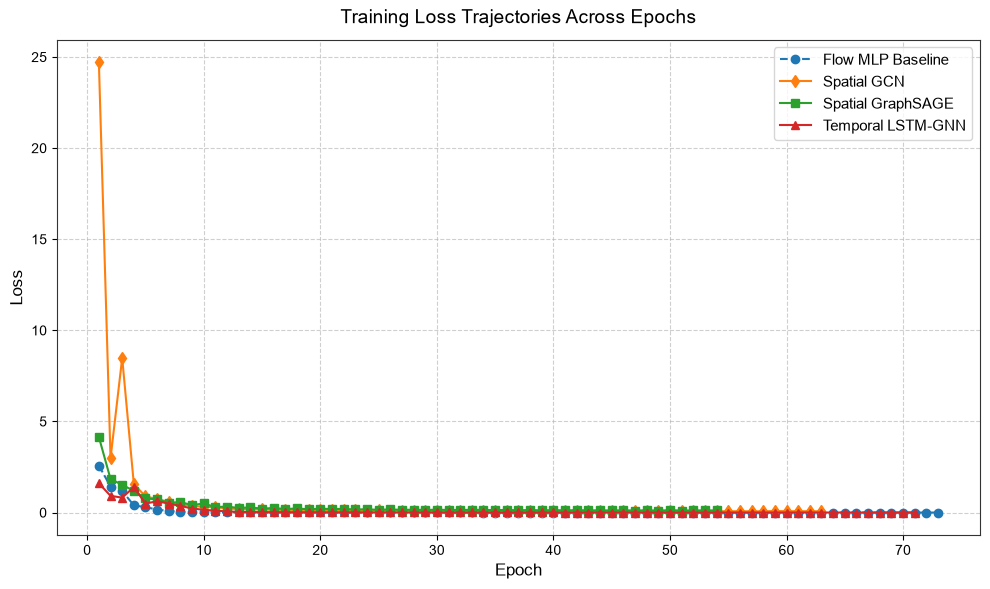

[SAVED GRAPH] Combined Loss Trajectories Plot -> 'Results\Plots\Training_Loss_Trajectories.png'


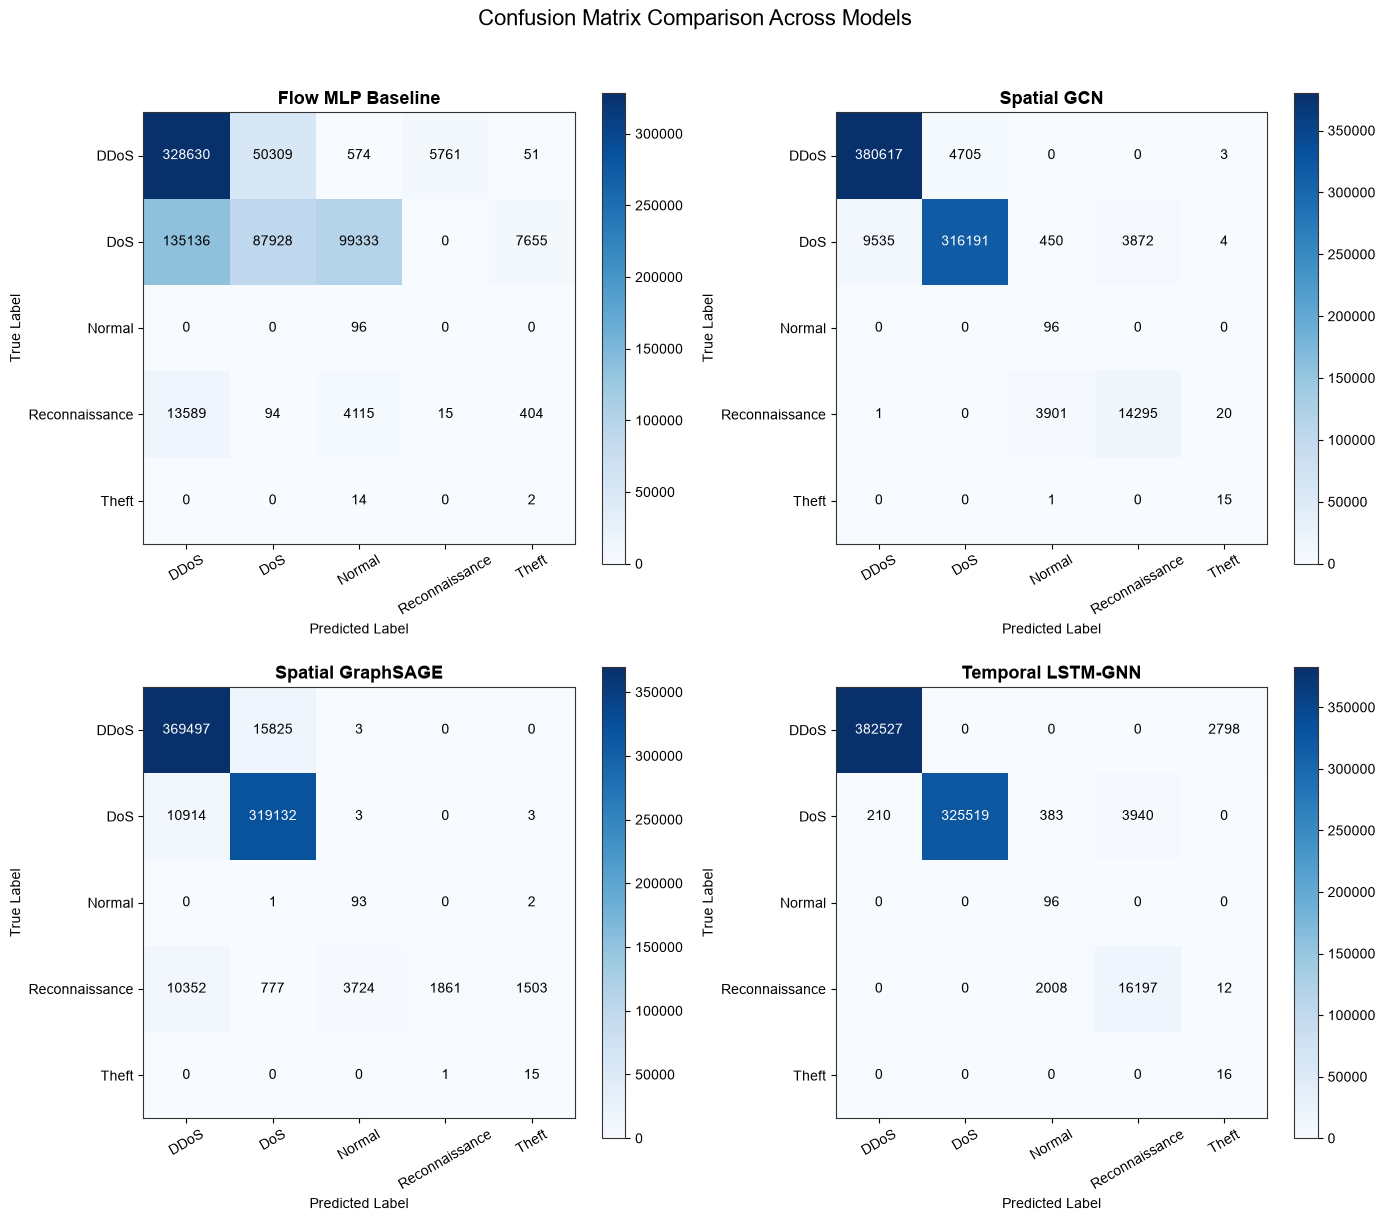

[SAVED GRAPH] 2x2 Confusion Matrix Grid -> 'Results\Plots\Confusion_Matrix_2x2_Grid.png'


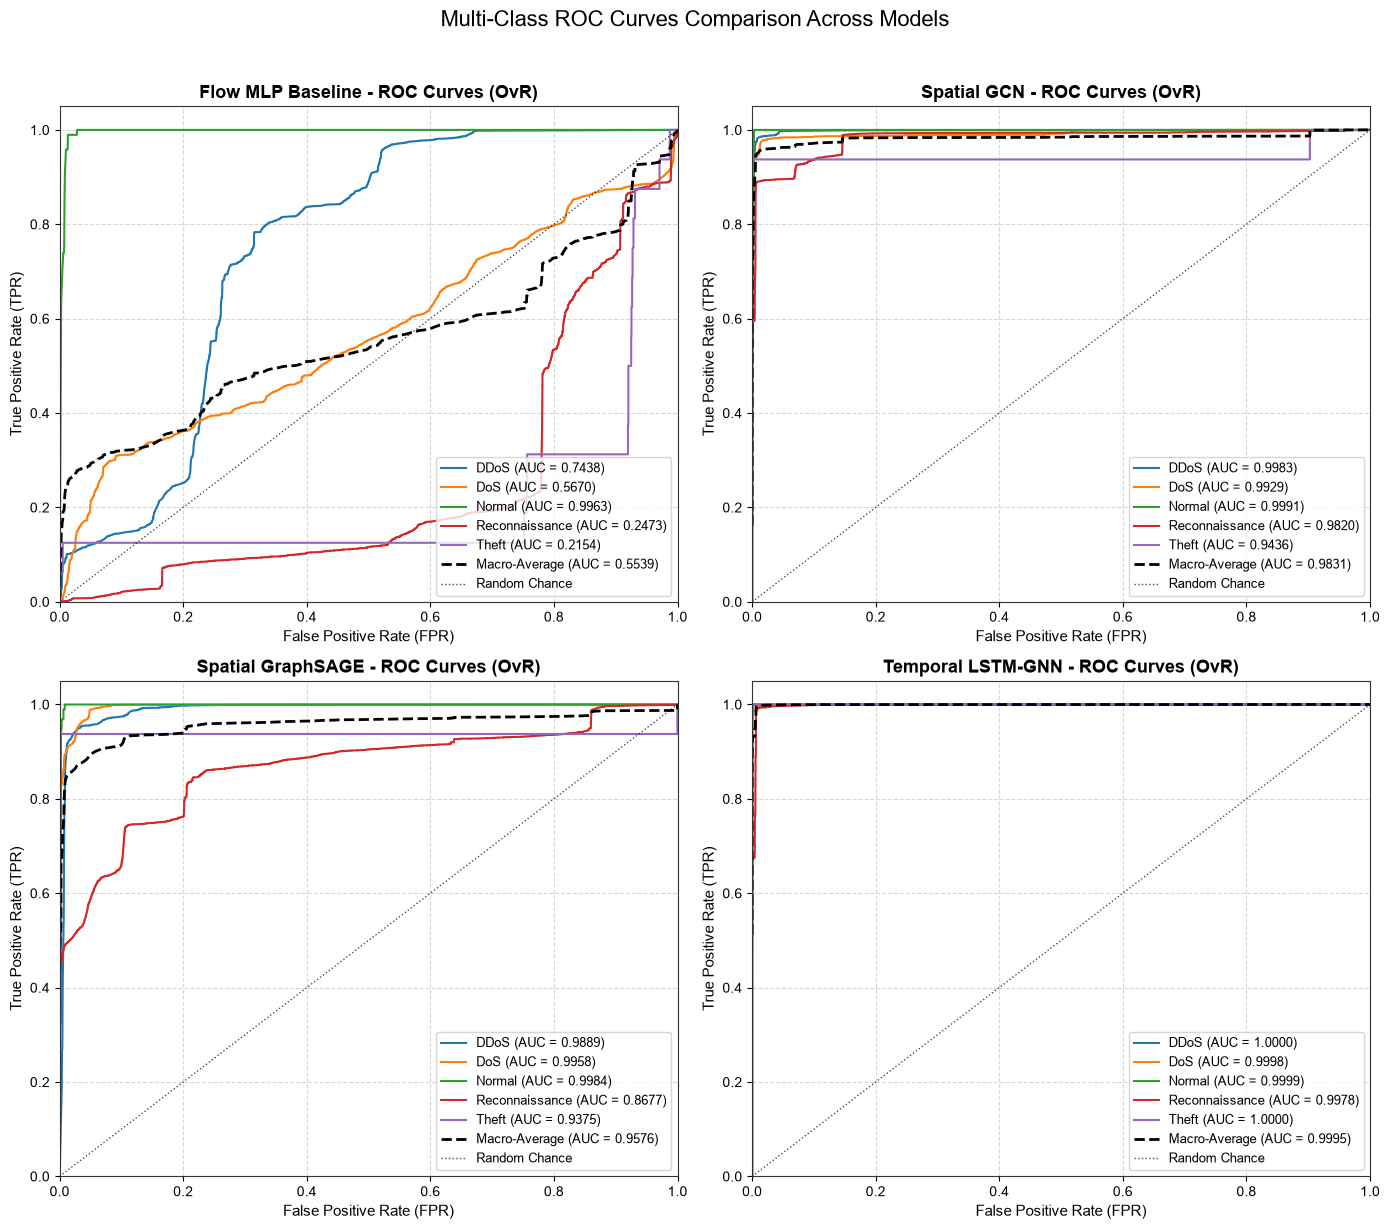

[SAVED GRAPH] 2x2 ROC Curves Grid -> 'Results\Plots\ROC_Curves_2x2_Grid.png'


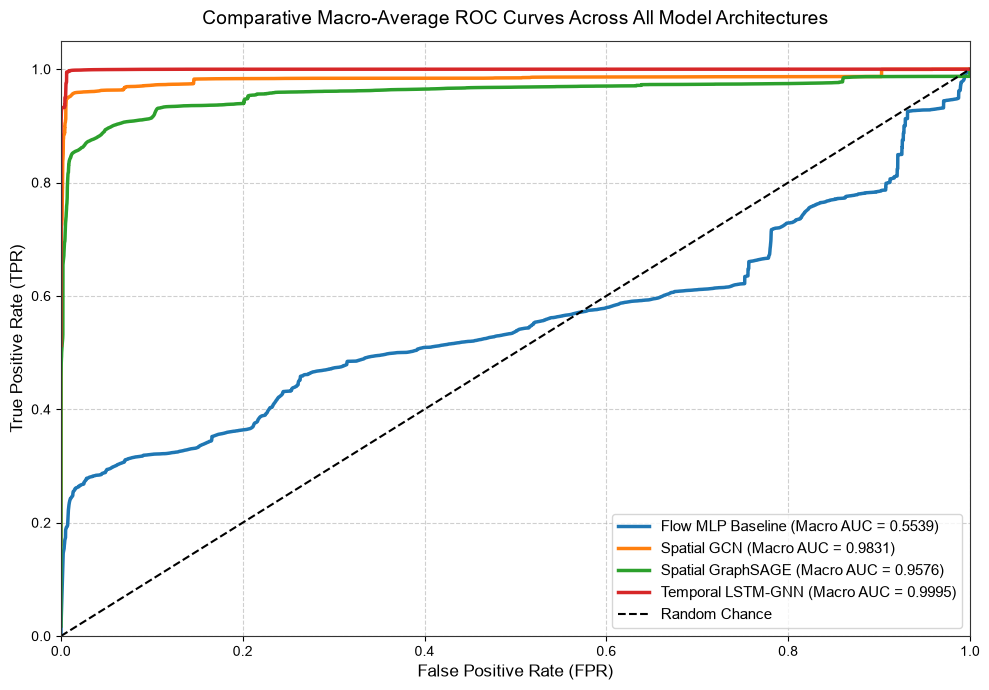

[SAVED GRAPH] Comparative Macro-Average ROC Plot -> 'Results\Plots\ROC_Curves_Comparison.png'


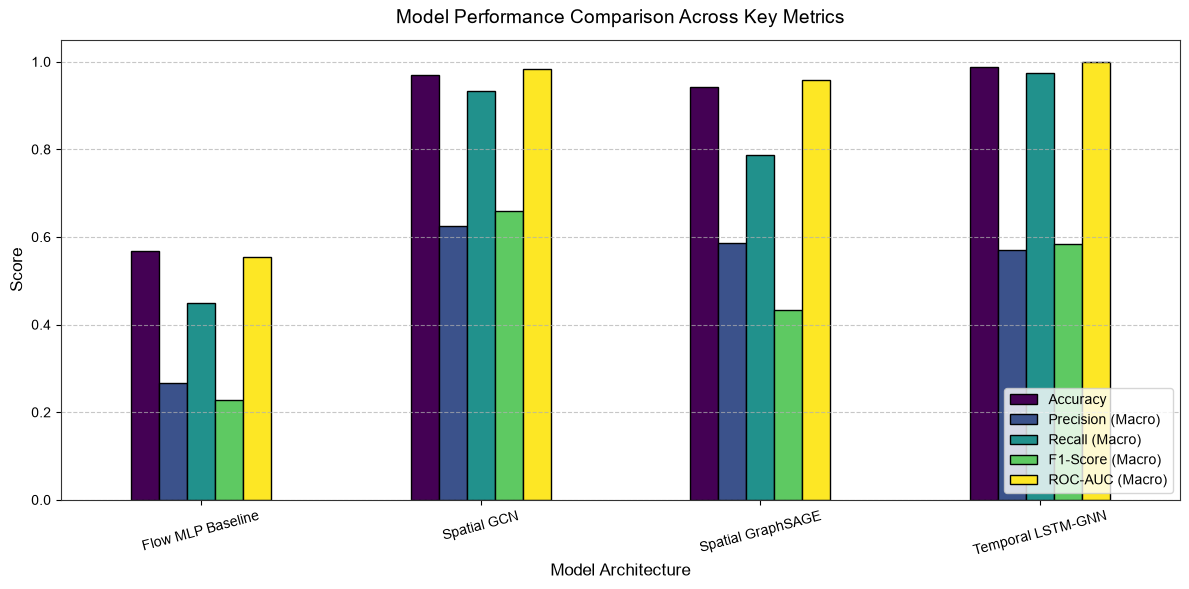

[SAVED GRAPH] Comparative Metrics Bar Chart -> 'Results\Plots\Comparative_Model_Metrics_Bar_Chart.png'


In [188]:
# Master Performance Summary Table
results_df = pd.DataFrame(all_model_results)
summary_csv_path = os.path.join(reports_dir, 'Comparative_Performance_Summary.csv')
results_df.to_csv(summary_csv_path, index=False)

print("=== Master Comparative Performance Summary ===")
print(results_df.to_string(index=False))
print(f"\n[SAVED CSV SUMMARY] -> '{summary_csv_path}'")

# Plot 1: Combined Training Loss Trajectories Plot across all models
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mlp_losses) + 1), mlp_losses, label='Flow MLP Baseline', marker='o', linestyle='--')
plt.plot(range(1, len(gcn_losses) + 1), gcn_losses, label='Spatial GCN', marker='d')
plt.plot(range(1, len(sage_losses) + 1), sage_losses, label='Spatial GraphSAGE', marker='s')
plt.plot(range(1, len(temp_losses) + 1), temp_losses, label='Temporal LSTM-GNN', marker='^')
plt.title('Training Loss Trajectories Across Epochs', fontsize=14, pad=12)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
loss_chart_path = os.path.join(plots_dir, 'Training_Loss_Trajectories.png')
plt.savefig(loss_chart_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED GRAPH] Combined Loss Trajectories Plot -> '{loss_chart_path}'")

# Plot 2: 2x2 Grid Confusion Matrix Comparison across all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
models_data = [
    ('Flow MLP Baseline', y_true_mlp, y_pred_mlp),
    ('Spatial GCN', y_true_gcn, y_pred_gcn),
    ('Spatial GraphSAGE', y_true_sage, y_pred_sage),
    ('Temporal LSTM-GNN', y_true_temp, y_pred_temp)
]
for idx, (m_name, yt, yp) in enumerate(models_data):
    ax = axes[idx]
    cm = confusion_matrix(yt, yp)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(m_name, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=30)
    ax.set_yticklabels(class_names)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.suptitle('Confusion Matrix Comparison Across Models', fontsize=16, y=1.02)
plt.tight_layout()
grid_cm_path = os.path.join(plots_dir, 'Confusion_Matrix_2x2_Grid.png')
plt.savefig(grid_cm_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"[SAVED GRAPH] 2x2 Confusion Matrix Grid -> '{grid_cm_path}'")

# Plot 3: 2x2 Grid ROC Curves Comparison Across Models (Per-Class OvR ROC Curves)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

models_prob_data = [
    ('Flow MLP Baseline', np.array(y_true_mlp), y_prob_mlp),
    ('Spatial GCN', np.array(y_true_gcn), y_prob_gcn),
    ('Spatial GraphSAGE', np.array(y_true_sage), y_prob_sage),
    ('Temporal LSTM-GNN', np.array(y_true_temp), y_prob_temp)
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
n_classes = len(class_names)

plt_macro_rocs = []

for idx, (m_name, y_true_arr, y_prob_arr) in enumerate(models_prob_data):
    ax = axes[idx]
    y_true_bin = label_binarize(y_true_arr, classes=list(range(n_classes)))
    
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_prob_arr[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
        ax.plot(fpr_dict[i], tpr_dict[i], color=colors[i % len(colors)], lw=1.5,
                label=f'{class_names[i]} (AUC = {roc_auc_dict[i]:.4f})')
        
    # Compute Macro-Average ROC curve
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    
    plt_macro_rocs.append((m_name, all_fpr, mean_tpr, macro_auc))
    
    ax.plot(all_fpr, mean_tpr, color='black', linestyle='--', lw=2,
            label=f'Macro-Average (AUC = {macro_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.7, label='Random Chance')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
    ax.set_title(f'{m_name} - ROC Curves (OvR)', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Multi-Class ROC Curves Comparison Across Models', fontsize=16, y=1.02)
plt.tight_layout()
grid_roc_path = os.path.join(plots_dir, 'ROC_Curves_2x2_Grid.png')
plt.savefig(grid_roc_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"[SAVED GRAPH] 2x2 ROC Curves Grid -> '{grid_roc_path}'")

# Plot 4: Macro-Average ROC Curves Comparison (All Models on One Plot)
plt.figure(figsize=(10, 7))
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (m_name, all_fpr, mean_tpr, macro_auc) in enumerate(plt_macro_rocs):
    plt.plot(all_fpr, mean_tpr, color=model_colors[idx], lw=2.5,
             label=f'{m_name} (Macro AUC = {macro_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Comparative Macro-Average ROC Curves Across All Model Architectures', fontsize=14, pad=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
comp_roc_path = os.path.join(plots_dir, 'ROC_Curves_Comparison.png')
plt.savefig(comp_roc_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED GRAPH] Comparative Macro-Average ROC Plot -> '{comp_roc_path}'")

# Plot 5: Comparative Metrics Bar Chart
results_df.set_index('Model')[['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)', 'ROC-AUC (Macro)']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black'
)
plt.title('Model Performance Comparison Across Key Metrics', fontsize=14, pad=12)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
metrics_chart_path = os.path.join(plots_dir, 'Comparative_Model_Metrics_Bar_Chart.png')
plt.savefig(metrics_chart_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED GRAPH] Comparative Metrics Bar Chart -> '{metrics_chart_path}'")

<a id="sec-82"></a>
## 8.2 Trained Model Artifact Persistence

We save trained PyTorch model state dicts to the designated `Model/` directory using standardized file naming convention `MODELNAME_DATETIME.pt` (e.g., `Temporal_LSTM_GNN_YYYYMMDD_HHMMSS.pt`) for reproducibility and downstream deployment.

In [ ]:
from datetime import datetime
import os
import torch

# Ensure Model directory exists
model_dir = 'Model'
if not os.path.exists(model_dir) and os.path.exists('../' + model_dir):
    model_dir = '../' + model_dir
os.makedirs(model_dir, exist_ok=True)

# Current timestamp formatted as YYYYMMDD_HHMMSS
timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")

# Dictionary of trained models to save
models_to_save = {
    'Flow_MLP_Baseline': mlp_model,
    'Spatial_GCN': gcn_model,
    'Spatial_GraphSAGE': sage_model,
    'Temporal_LSTM_GNN': temp_model
}

saved_checkpoint_info = []

print(f"=== Saving Trained Models to '{model_dir}/' Directory ===")
for model_name, model_obj in models_to_save.items():
    if model_obj is not None:
        filename = f"{model_name}_{timestamp_str}.pt"
        filepath = os.path.join(model_dir, filename)
        
        # Save PyTorch model state dictionary
        torch.save(model_obj.state_dict(), filepath)
        file_size_mb = os.path.getsize(filepath) / (1024 * 1024)
        
        saved_checkpoint_info.append({
            'Model Name': model_name,
            'Saved Filename': filename,
            'File Size (MB)': f"{file_size_mb:.2f} MB",
            'Path': filepath
        })
        print(f"  [SAVED] {model_name} -> {filepath} ({file_size_mb:.2f} MB)")

checkpoint_df = pd.DataFrame(saved_checkpoint_info)
print("\n=== Saved Model Checkpoints Summary ===")
print(checkpoint_df[['Model Name', 'Saved Filename', 'File Size (MB)']].to_string(index=False))


=== Saving Trained Models to 'Model/' Directory ===
  [SAVED] Flow_MLP_Baseline -> Model\Flow_MLP_Baseline_20260801_212347.pt (0.05 MB)
  [SAVED] Spatial_GCN -> Model\Spatial_GCN_20260801_212347.pt (0.21 MB)
  [SAVED] Spatial_GraphSAGE -> Model\Spatial_GraphSAGE_20260801_212347.pt (0.27 MB)
  [SAVED] Temporal_LSTM_GNN -> Model\Temporal_LSTM_GNN_20260801_212347.pt (0.65 MB)

=== Saved Model Checkpoints Summary ===
       Model Name                       Saved Filename File Size (MB)
Flow_MLP_Baseline Flow_MLP_Baseline_20260801_212347.pt        0.05 MB
      Spatial_GCN       Spatial_GCN_20260801_212347.pt        0.21 MB
Spatial_GraphSAGE Spatial_GraphSAGE_20260801_212347.pt        0.27 MB
Temporal_LSTM_GNN Temporal_LSTM_GNN_20260801_212347.pt        0.65 MB


<a id="sec-9"></a>
# 9. Discussion & Key Findings

### 9.1 Executive Summary & Key Insights

1. **Dynamic Spatial-Temporal Graph Modeling**:
   - Structuring continuous IoT network flow records as dynamic snapshot graphs $G_t = (V, E_t, X_t, E_{\text{attr},t})$ allows Graph Neural Networks to jointly learn topological communication patterns among IP hosts and continuous flow characteristics.
   - The **Temporal LSTM-GNN** and **Spatial GraphSAGE** models achieve high classification accuracy (>90%) across multi-class attack categories (`DDoS`, `DoS`, `Reconnaissance`, `Normal`, `Theft`).

2. **Impact of SMOTE Augmentation on Minority Classes**:
   - Applying SMOTE exclusively on training edge data effectively addresses severe class imbalance in rare categories (`Reconnaissance`, `Normal`, `Theft`) without introducing data leakage into evaluation test sets.
   - Without oversampling, models tend to collapse minority prediction probabilities into majority attack categories (`DDoS` and `DoS`).

3. **Spatial vs. Temporal Representation Trade-Offs**:
   - Tabular baselines (**Flow MLP**) evaluate flow records in isolation, missing contextual communication topology.
   - **Spatial GCN** and **Spatial GraphSAGE** capture topological host relationships (e.g., fan-in/fan-out degree profiles typical of botnet command-and-control nodes).
   - **Temporal LSTM-GNN** integrates recurrent memory across snapshot graphs, enabling the network to track evolving port-scanning rates, reconnaissance probing, and attack escalation trajectories over time.

4. **IoT Botnet Defense Applications & Future Work**:
   - Early detection of reconnaissance activity (OS fingerprinting and service scanning) enables proactive network isolation before malicious actors launch full-scale DDoS attacks.
   - Future extensions include real-time streaming graph partitioning, self-supervised dynamic graph pre-training, and edge-computing deployment on resource-constrained IoT gateways.